# **Proyecto ABP 9: Fundamentos de Big Data - *Retail Analytics Pipeline***

**Autora:** Bernardita Ortega.

**Dataset:** Brazilian E-Commerce Public Dataset by Olist.

**Tablas utilizadas**:
- olist_orders_dataset.csv
- olist_order_items_dataset.csv
- olist_order_reviews_dataset.csv
- olist_products_dataset.csv

**Link**: *https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce*

### **Situación inicial 📍**

#### **Unidad solicitante: Departamento de Analítica y Machine Learning de la empresa RetailMax.**

La empresa RetailMax maneja millones de transacciones diarias en su plataforma e-commerce, lo que genera grandes volúmenes de datos provenientes de compras, comportamiento de navegación, reseñas y calificaciones. Actualmente, el proceso de análisis es lento y fragmentado: los datos se almacenan en múltiples sistemas y los modelos de Machine Learning tradicionales no pueden escalar a la magnitud del dataset.

El área de analítica solicita desarrollar un pipeline de Big Data y Machine Learning escalable, capaz de:
1. Procesar datos estructurados y no estructurados en entornos distribuidos.
2. Ejecutar transformaciones masivas para generar métricas de negocio.
3. Entrenar y evaluar modelos de Machine Learning sobre grandes volúmenes de datos utilizando Spark MLlib.


### **Nuestro objetivo 📋**
Diseñar e implementar un proyecto integral que comience con la ingesta y procesamiento de datos masivos, continúe con la transformación y análisis mediante Apache Spark, y finalice con la construcción de un modelo de Machine Learning escalable que permita clasificar usuarios y generar información accionable para el área de marketing.

El proyecto demostrará que el participante es capaz de aplicar los fundamentos de Big Data y Spark, trabajando con RDDs, DataFrames, SQL y MLlib, en un flujo completo de análisis masivo.

## **Lección 1 - *Fundamentos de Big Data***

📌 **Objetivo:** Reconocer el ecosistema de Big Data y sus componentes básicos.

📍 **Tareas solicitadas en el ejercicio:**
1. Describir las 5V de Big Data y su impacto en proyectos reales.
2. Identificar fuentes de datos de RetailMax (transacciones, reseñas, navegación).
3. Proponer un diagrama inicial de arquitectura para el proyecto.
4. Entregar un informe conceptual que sirva como base para las siguientes etapas.

1. **Describir las 5V de Big Data y su impacto en proyectos reales.**

El concepto de Big Data está definido por un conjunto de características fundamentales conocidas como las 5V’s. Estas dimensiones permiten comprender la complejidad y los desafíos asociados al manejo de datos masivos. Las 5V’s son:

- **Volumen** hace referencia a la enorme cantidad de datos que se generan diariamente desde múltiples fuentes. Las organizaciones deben gestionar desde terabytes hasta petabytes de información, lo que requiere soluciones de almacenamiento escalables que los sistemas tradicionales no pueden manejar.

  Por ejemplo, en el sector financiero, los bancos procesan millones de transacciones diarias. Sin infraestructura distribuida como Hadoop o Spark, sería imposible almacenar y analizar ese volumen para detectar fraudes o calcular riesgos en tiempo real.

- **Velocidad** se refiere a la rápidez con la que los datos son generados, procesados y analizados. En la era digital, los datos fluyen de manera continua desde sensores, redes sociales, transacciones financieras y dispositivos móviles, exigiendo procesamiento casi en tiempo real.

  Por ejemplo, las plataformas de streaming como Netflix o Paramount analizan el comportamiento de sus millones de usuarios en tiempo real para actualizar sus algoritmos de recomendación. Cada clic, pausa o búsqueda alimenta el sistema instantáneamente. Un sistema tradicional con procesamiento por lotes no podría sostener esa experiencia personalizada. Otro ejemplo ocurre en el sistema de transporte público Transantiago, el cuál genera datos en tiempo real desde miles de validaciones de tarjeta Bip! por hora. Procesar esa información al instante permite ajustar frecuencias de recorrido, detectar colapsos en estaciones y mejorar la planificación del servicio.

- **Variedad** describe la diversidad de formatos y tipos de datos. A diferencia de los sistemas tradicionales que gestionan solo datos estructurados, en Big Data es común trabajar con datos no estructurados como textos, imágenes, videos y registros de sensores.

  Por ejemplo, en salud, hospitales como el Mayo Clinic combinan historiales médicos estructurados (tablas de base de datos), imágenes de radiografías (datos no estructurados) y notas de médicos en texto libre (semiestructurado) para construir modelos predictivos de diagnóstico. Integrar esa variedad requiere pipelines Big Data especializados. Otro ejemplo es que el Ministerio de Salud durante la pandemia combinó datos estructurados (planillas de casos PCR), datos semiestructurados (reportes de laboratorios en JSON) y datos no estructurados (declaraciones de autoridades y noticias) para construir el dashboard COVID-19 que monitoreaba la situación sanitaria del país.

- **Veracidad** hace referencia a la calidad y confiabilidad de los datos. No todos los datos recopilados son precisos o relevantes — pueden contener inconsistencias, duplicados o información errónea. Es fundamental implementar mecanismos de limpieza y validación antes del análisis.

  Por ejemplo, en campañas de marketing digital, las empresas enfrentan el problema de datos de clientes duplicados, incompletos o incorrectos provenientes de múltiples canales (redes sociales, tiendas físicas, e-commerce, etc). Sin procesos de validación y limpieza, los modelos de segmentación generan resultados incorrectos y campañas mal dirigidas. Un ejmploe en Chile, sería que el Servicio de Impuestos Internos (SII) recibe declaraciones de renta de millones de contribuyentes con datos inconsistentes, duplicados o mal ingresados. Sin procesos de validación y limpieza de datos, los cruces de información para detectar evasión tributaria generarían resultados incorrectos.

- **Valor** es la dimensión más importante: de nada sirve recopilar grandes volúmenes de datos si no se puede extraer información útil. El objetivo final de cualquier estrategia Big Data es transformar los datos en conocimiento que genere valor para la organización.

    Por ejemplo, Amazon usa Big Data para optimizar su cadena de logística. Analizando patrones de compra, ubicación de clientes y condiciones climáticas predice qué productos mover a cada depósito antes de que sean pedidos. Esto redujo sus tiempos de entrega y costos operativos significativamente. En Chile, Falabella utiliza Big Data para analizar el comportamiento de compra de sus clientes a través de sus canales físicos, online y CMR. Con esa información genera recomendaciones personalizadas, optimiza el inventario por tienda y diseña campañas de marketing segmentadas por región y perfil de consumidor.

2. **Identificar fuentes de datos de RetailMax (transacciones, reseñas, navegación).**

Se utilizará el dataset de Olist. Este es el mayor marketplace de Brasil, con más de 100.000 pedidos registrados entre 2016 y 2018. Su ecosistema de datos es un ejemplo real de Big Data. En este caso usaremos las siguientes fuentes de datos del proyecto:

| Archivo | Contenido | Columnas clave |
|---------|-----------|----------------|
| `olist_orders_dataset.csv` | Información general de pedidos | order_id, order_status, timestamps |
| `olist_order_items_dataset.csv` | Detalle de ítems vendidos por pedido | order_id, price, freight_value |
| `olist_order_reviews_dataset.csv` | Puntuaciones y reseñas de clientes | order_id, review_score |
| `olist_products_dataset.csv` | Productos: catálogo y categorías de producto | product_id, product_category_name |

3. **Proponer un diagrama inicial de arquitectura para el proyecto.**

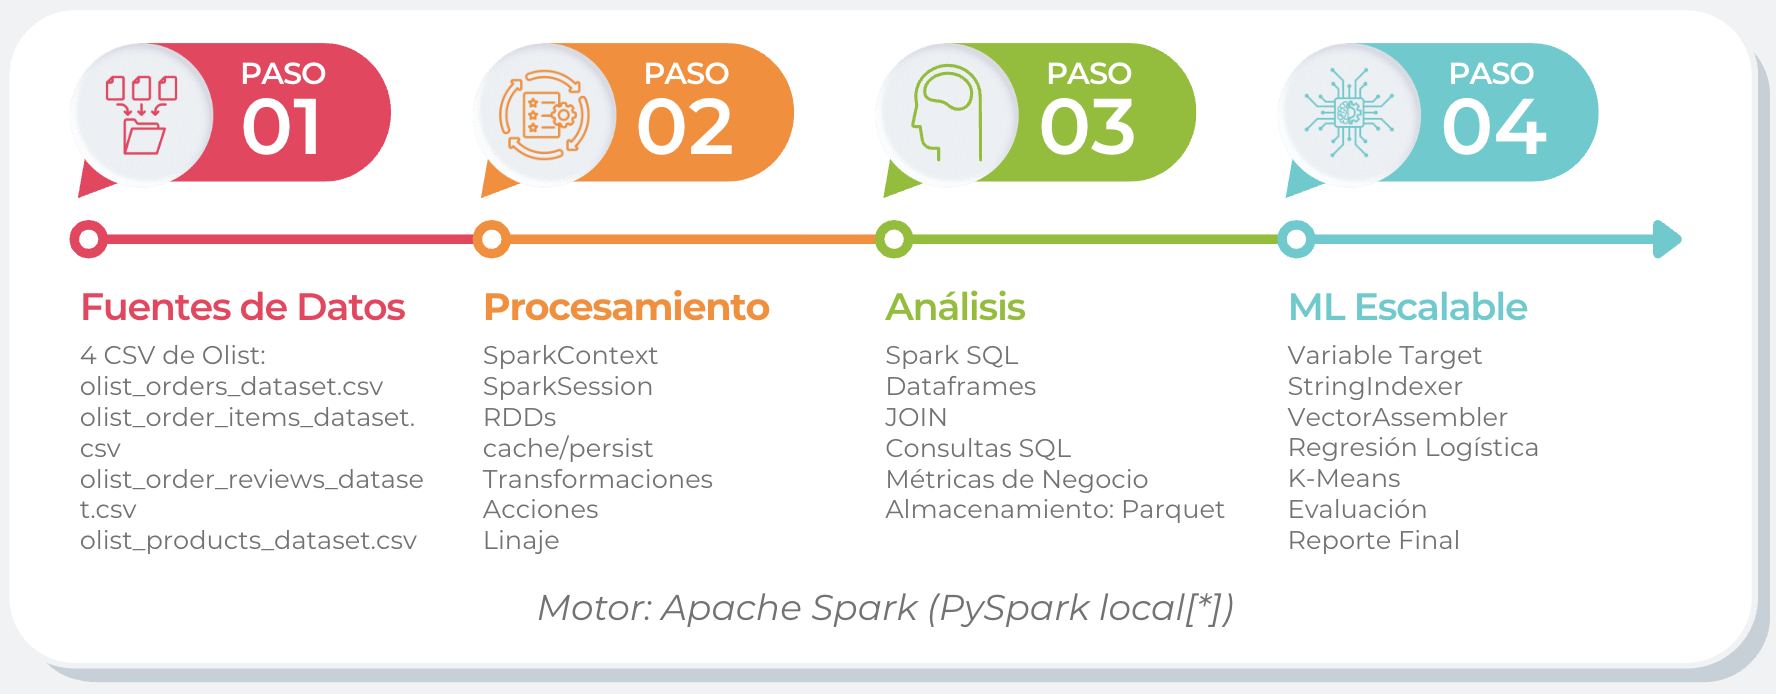

## **Lección 2 - *Apache Spark - Introducción y Configuración***

📌 **Objetivo:** Configurar Spark e iniciar el procesamiento distribuido de datos masivos.

📍 **Tareas solicitadas en el ejercicio:**
1. Configurar SparkContext y SparkSession en un entorno local o clúster.
2. Cargar datos iniciales en RDDs y explorar acciones básicas (count, take).
3. Validar conectividad con datasets masivos de prueba.
4. Entregar un notebook con la configuración y prueba inicial.

In [194]:
!pip install pyspark

In [195]:
# Importación
from pyspark import SparkContext, SparkConf
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import pandas as pd

In [196]:
# Rutas del dataset
DATA_PATH = "/content/"
OUT_PATH  = "/content/"

In [197]:
# Configuración de Spark
# SparkContext: punto de entrada para RDDs
conf = SparkConf().setAppName("OlistAnalyticsPipeline").setMaster("local[*]")
sc = SparkContext.getOrCreate(conf)

# SparkSession: punto de entrada para DataFrames y SQL
spark = SparkSession.builder.appName("OlistAnalyticsPipeline").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

print(sc)
print(f"Spark version: {spark.version}")

<SparkContext master=local[*] appName=OlistAnalyticsPipeline>
Spark version: 4.0.2


In [198]:
# Carga inicial de Pedidos Realizados (orders) en RDD — validación de conectividad
rdd_orders_raw = sc.textFile(DATA_PATH + "olist_orders_dataset.csv")

print(f"Total de líneas en Pedidos Realizados (orders): {rdd_orders_raw.count()}")
print(f"Primeras líneas: {rdd_orders_raw.collect()[:3]}")

Total de líneas en Pedidos Realizados (orders): 99442
Primeras líneas: ['"order_id","customer_id","order_status","order_purchase_timestamp","order_approved_at","order_delivered_carrier_date","order_delivered_customer_date","order_estimated_delivery_date"', 'e481f51cbdc54678b7cc49136f2d6af7,"9ef432eb6251297304e76186b10a928d",delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00', '"53cdb2fc8bc7dce0b6741e2150273451",b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00']


In [199]:
# Carga inicial de Ítems por Pedido (order_items) en RDD — validación de conectividad
rdd_items_raw = sc.textFile(DATA_PATH + "olist_order_items_dataset.csv")

print(f"Total de líneas en Ítems por Pedido (order_items): {rdd_items_raw.count()}")
print(f"Primeras líneas: {rdd_items_raw.collect()[:3]}")

Total de líneas en Ítems por Pedido (order_items): 112651
Primeras líneas: ['"order_id","order_item_id","product_id","seller_id","shipping_limit_date","price","freight_value"', '"00010242fe8c5a6d1ba2dd792cb16214",1,"4244733e06e7ecb4970a6e2683c13e61","48436dade18ac8b2bce089ec2a041202",2017-09-19 09:45:35,58.90,13.29', '"00018f77f2f0320c557190d7a144bdd3",1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93']


In [200]:
# Carga inicial de Reseñas de Clientes (reviews) en RDD — validación de conectividad
rdd_reviews_raw = sc.textFile(DATA_PATH + "olist_order_reviews_dataset.csv")

print(f"Total de líneas en  Reseñas de Clientes (reviews): {rdd_reviews_raw.count()}")
print(f"Primeras líneas: {rdd_reviews_raw.collect()[:3]}")

Total de líneas en  Reseñas de Clientes (reviews): 104720
Primeras líneas: ['"review_id","order_id","review_score","review_comment_title","review_comment_message","review_creation_date","review_answer_timestamp"', '"7bc2406110b926393aa56f80a40eba40","73fc7af87114b39712e6da79b0a377eb",4,,,2018-01-18 00:00:00,2018-01-18 21:46:59', '"80e641a11e56f04c1ad469d5645fdfde","a548910a1c6147796b98fdf73dbeba33",5,,,2018-03-10 00:00:00,2018-03-11 03:05:13']


In [201]:
# Carga inicial de Productos (products) en RDD — validación de conectividad
rdd_products_raw = sc.textFile(DATA_PATH + "olist_products_dataset.csv")

print(f"Total de líneas en Productos (products): {rdd_products_raw.count()}")
print(f"Primeras líneas: {rdd_products_raw.collect()[:3]}")

Total de líneas en Productos (products): 32952
Primeras líneas: ['"product_id","product_category_name","product_name_lenght","product_description_lenght","product_photos_qty","product_weight_g","product_length_cm","product_height_cm","product_width_cm"', '"1e9e8ef04dbcff4541ed26657ea517e5",perfumaria,40,287,1,225,16,10,14', '"3aa071139cb16b67ca9e5dea641aaa2f",artes,44,276,1,1000,30,18,20']


## **Lección 3 - *Elementos básicos de Spark (RDD, Transformaciones y Acciones)***

📌 **Objetivo:** Manipular grandes volúmenes de datos mediante RDDs, aplicando transformaciones y acciones.

📍 **Tareas solicitadas en el ejercicio:**
1. Crear RDDs y Pair RDDs a partir de datos de transacciones.
2. Aplicar transformaciones (map, filter, flatMap, distinct, sortBy).
3. Ejecutar acciones (collect, sum, mean, stdev) y documentar el linaje.
4. Entregar notebook con código funcional y explicación del DAG generado.

Se utilizó **Ítems por Pedido (olist_order_items_dataset.csv)**, ya que tiene columnas de tipo numéricas, como son: número de pedido (*order_id*), precio (*price*), y flete (*freight_value*). Las cuales permiten calcular y/o prácticar lo solicitado en esta lección.

In [202]:
# Creación del RDD de Ítems por Pedido (order_items)
header_items = rdd_items_raw.first()

rdd_items = rdd_items_raw \
    .filter(lambda linea: linea != header_items) \
    .map(lambda linea: linea.split(",")) \
    .filter(lambda c: len(c) == 7) \
    .map(lambda c: (
        c[0].strip('"'),    # order_id
        int(c[1]),          # order_item_id
        c[2].strip('"'),    # product_id
        c[3].strip('"'),    # seller_id
        c[4],               # shipping_limit_date
        float(c[5]),        # price
        float(c[6])         # freight_value
    ))

print(f"Registros en rdd_items: {rdd_items.count()}")

Registros en rdd_items: 112650


In [203]:
# Persistencia - cache()
rdd_items.cache()
print(f"RDD persistido en memoria (cache)")
print(f"Número de particiones: {rdd_items.getNumPartitions()}")

RDD persistido en memoria (cache)
Número de particiones: 2


In [204]:
# Transformaciones

# filter: ítems con precio > 200 BRL
rdd_precio_alto = rdd_items.filter(lambda r: r[5] > 200.0)

# map: (order_id, precio_total) donde: total = price + freight
rdd_order_total = rdd_items.map(lambda r: (r[0], round(r[5] + r[6], 2)))

# map: (seller_id, price) para análisis por vendedor
rdd_seller_price = rdd_items.map(lambda r: (r[3], r[5]))

# map: solo precios para estadísticas
rdd_precios = rdd_items.map(lambda r: r[5])

# distinct: vendedores únicos
rdd_sellers_uniq = rdd_items.map(lambda r: r[3]).distinct()

# sortBy: ítems más caros primero
rdd_top_precio = rdd_items.sortBy(lambda r: r[5], ascending=False)

# flatMap: separa la fecha de envío en partes (fecha y hora)
rdd_fechas = rdd_items.flatMap(lambda r: r[4].split(" "))

In [205]:
# Acciones
print("Acciones sobre Ítems por Pedido (order_items)")
print(f"\nTotal ítems                : {rdd_items.count()}")
print(f"Ítems con precio > 200 BRL : {rdd_precio_alto.count()}")
print(f"Vendedores únicos          : {rdd_sellers_uniq.count()}")
print(f"Primeros 5 ítems del RDD   : {rdd_items.collect()[:5]}")
print(f"Ejemplo de fechas separadas: {rdd_fechas.take(6)}")

print("\nTop 5 ítems más caros:")
for r in rdd_top_precio.take(5):
    print(f"  order_id={r[0]} | ${r[5]:.2f} | flete ${r[6]:.2f}")

print(f"\nEstadísticas de precio (BRL):")
print(f"Total      = {rdd_precios.sum():,.2f}")
print(f"Promedio   = {rdd_precios.mean():.2f}")
print(f"Desv. Est. = {rdd_precios.stdev():.2f}")

Acciones sobre Ítems por Pedido (order_items)

Total ítems                : 112650
Ítems con precio > 200 BRL : 13374
Vendedores únicos          : 3095
Primeros 5 ítems del RDD   : [('00010242fe8c5a6d1ba2dd792cb16214', 1, '4244733e06e7ecb4970a6e2683c13e61', '48436dade18ac8b2bce089ec2a041202', '2017-09-19 09:45:35', 58.9, 13.29), ('00018f77f2f0320c557190d7a144bdd3', 1, 'e5f2d52b802189ee658865ca93d83a8f', 'dd7ddc04e1b6c2c614352b383efe2d36', '2017-05-03 11:05:13', 239.9, 19.93), ('000229ec398224ef6ca0657da4fc703e', 1, 'c777355d18b72b67abbeef9df44fd0fd', '5b51032eddd242adc84c38acab88f23d', '2018-01-18 14:48:30', 199.0, 17.87), ('00024acbcdf0a6daa1e931b038114c75', 1, '7634da152a4610f1595efa32f14722fc', '9d7a1d34a5052409006425275ba1c2b4', '2018-08-15 10:10:18', 12.99, 12.79), ('00042b26cf59d7ce69dfabb4e55b4fd9', 1, 'ac6c3623068f30de03045865e4e10089', 'df560393f3a51e74553ab94004ba5c87', '2017-02-13 13:57:51', 199.9, 18.14)]
Ejemplo de fechas separadas: ['2017-09-19', '09:45:35', '2017-05-03',

Los datos muestran que Olist tiene 112.650 ítems en total, de los cuales 13.374 tienen precio mayor a 200 BRL.

El precio promedio por ítem es de BRL 120.65 con una desviación estándar de BRL 183.45, lo que indica gran dispersión en los precios.

In [206]:
# Total por pedido
total_por_order = rdd_order_total \
    .reduceByKey(lambda a, b: round(a + b, 2))

valores_pedido = total_por_order.map(lambda x: x[1])

print(f"Pedidos únicos en order_items : {total_por_order.count()}")
print(f"Valor promedio por pedido     : BRL {valores_pedido.mean():.2f}")
print(f"Desvío estándar               : BRL {valores_pedido.stdev():.2f}")

Pedidos únicos en order_items : 98666
Valor promedio por pedido     : BRL 160.58
Desvío estándar               : BRL 220.46


In [207]:
# Pair RDD - ingresos totales por vendedor (reduceByKey)
ingresos_por_seller = rdd_seller_price \
    .reduceByKey(lambda a, b: round(a + b, 2)) \
    .sortBy(lambda x: x[1], ascending=False)

print("Top 10 vendedores por ingresos (BRL):")
for seller, total in ingresos_por_seller.take(10):
    print(f"  {seller}  BRL {total:,.2f}")

Top 10 vendedores por ingresos (BRL):
  4869f7a5dfa277a7dca6462dcf3b52b2  BRL 229,472.63
  53243585a1d6dc2643021fd1853d8905  BRL 222,776.05
  4a3ca9315b744ce9f8e9374361493884  BRL 200,472.92
  fa1c13f2614d7b5c4749cbc52fecda94  BRL 194,042.03
  7c67e1448b00f6e969d365cea6b010ab  BRL 187,923.89
  7e93a43ef30c4f03f38b393420bc753a  BRL 176,431.87
  da8622b14eb17ae2831f4ac5b9dab84a  BRL 160,236.57
  7a67c85e85bb2ce8582c35f2203ad736  BRL 141,745.53
  1025f0e2d44d7041d6cf58b6550e0bfa  BRL 138,968.55
  955fee9216a65b617aa5c0531780ce60  BRL 135,171.70


In [208]:
# Linaje del RDD de ingresos por vendedor
print(ingresos_por_seller.toDebugString().decode())

(2) PythonRDD[11178] at RDD at PythonRDD.scala:56 []
 |  MapPartitionsRDD[11176] at mapPartitions at PythonRDD.scala:168 []
 |  ShuffledRDD[11175] at partitionBy at NativeMethodAccessorImpl.java:0 []
 +-(2) PairwiseRDD[11174] at sortBy at /tmp/ipykernel_30608/7310456.py:4 []
    |  PythonRDD[11173] at sortBy at /tmp/ipykernel_30608/7310456.py:4 []
    |  MapPartitionsRDD[11170] at mapPartitions at PythonRDD.scala:168 []
    |  ShuffledRDD[11169] at partitionBy at NativeMethodAccessorImpl.java:0 []
    +-(2) PairwiseRDD[11168] at reduceByKey at /tmp/ipykernel_30608/7310456.py:3 []
       |  PythonRDD[11167] at reduceByKey at /tmp/ipykernel_30608/7310456.py:3 []
       |  PythonRDD[11141] at RDD at PythonRDD.scala:56 []
       |      CachedPartitions: 2; MemorySize: 11.0 MiB; DiskSize: 0.0 B
       |  /content/olist_order_items_dataset.csv MapPartitionsRDD[11131] at textFile at NativeMethodAccessorImpl.java:0 []
       |  /content/olist_order_items_dataset.csv HadoopRDD[11130] at textFil

**Jobs, Stages y Tasks en Spark**

Cada acción ejecutada sobre un RDD o DataFrame genera un **Job** en Spark. Cada Job se divide en **Stages** (etapas) separadas por shuffles de datos, y cada Stage se divide en **Tasks** que se ejecutan en paralelo en los distintos nodos del clúster.

Por ejemplo, al ejecutar rdd_items.count():
- Spark genera 1 Job
- El Job se divide en Stages según las transformaciones acumuladas
- Cada Stage ejecuta Tasks en paralelo sobre las particiones del RDD

En el linaje presentado anteriormente de ingresos_por_seller para obtener el top 10 de vendedores Spark ejecutó el siguiente flujo (de abajo hacia arriba) o generó un Job con múltiples Stages:
- **Stage 1:** leer CSV y aplicar cache
- **Stage 2:** extraer (seller_id, price) con map
- **Stage 3:** sumar por seller con reduceByKey (shuffle)
- **Stage 4:** ordenar y tomar top 10

Esto se puede visualizar en el Spark UI (http://localhost:4040) durante la ejecución, donde se pueden monitorear Jobs, Stages y Tasks en tiempo real. En este notebook usamos local[*] que simula un clúster usando todos los cores disponibles de la máquina local.

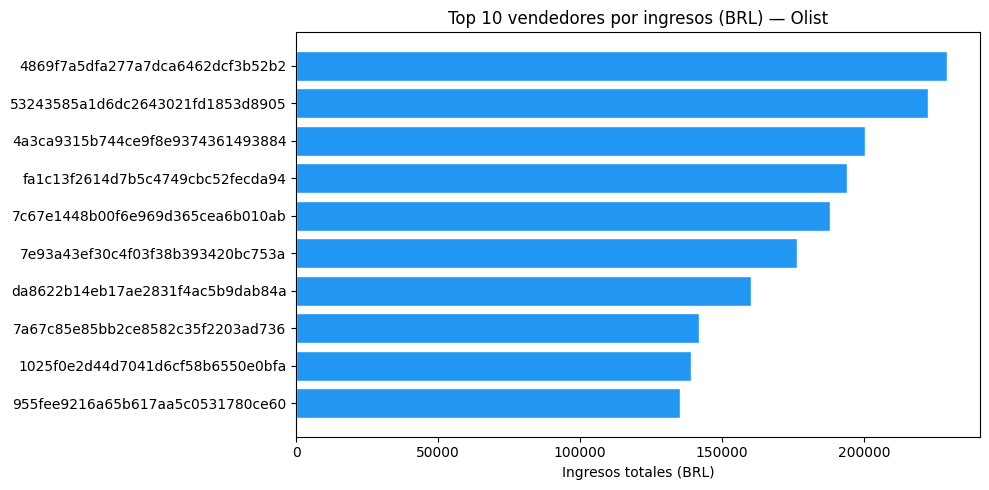

In [209]:
# Visualización Top 10 vendedores por ingresos
top_sellers = ingresos_por_seller.collect()[:10]
sellers_labels = [s for s, _ in top_sellers]
sellers_vals   = [v for _, v in top_sellers]

plt.figure(figsize=(10, 5))
plt.barh(sellers_labels[::-1], sellers_vals[::-1], color="#2196F3", edgecolor="white")
plt.title("Top 10 vendedores por ingresos (BRL) — Olist")
plt.xlabel("Ingresos totales (BRL)")
plt.tight_layout()
plt.savefig(OUT_PATH + "top_vendedores.png", dpi=120)
plt.show()

## **Lección 4 - *Procesamiento de datos estructurados (Spark SQL y DataFrames)***

📌 **Objetivo:** Procesar y analizar datos estructurados de manera optimizada usando DataFrames y Spark SQL.

📍 **Tareas solicitadas en el ejercicio:**
1. Transformar los RDDs generados en DataFrames y aplicar esquemas explícitos.
2. Ejecutar consultas SQL para generar métricas de negocio (ventas por categoría, top productos).
3. Guardar resultados en formato Parquet para la siguiente lección.
4. Entregar notebook + archivo Parquet generado.

In [210]:
# Importación
from pyspark.sql.functions import col, sum, when, avg, count, round as spark_round
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, FloatType

In [211]:
# Convertir Ítems por Pedido (rdd_items) a DataFrame con esquema explícito
schema_items = StructType([
    StructField("order_id",            StringType(),  True),
    StructField("order_item_id",       IntegerType(), True),
    StructField("product_id",          StringType(),  True),
    StructField("seller_id",           StringType(),  True),
    StructField("shipping_limit_date", StringType(),  True),
    StructField("price",               FloatType(),   True),
    StructField("freight_value",       FloatType(),   True)
])

df_items = spark.createDataFrame(rdd_items, schema=schema_items)
df_items.printSchema()
df_items.show(5)

root
 |-- order_id: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- shipping_limit_date: string (nullable = true)
 |-- price: float (nullable = true)
 |-- freight_value: float (nullable = true)

+--------------------+-------------+--------------------+--------------------+-------------------+-----+-------------+
|            order_id|order_item_id|          product_id|           seller_id|shipping_limit_date|price|freight_value|
+--------------------+-------------+--------------------+--------------------+-------------------+-----+-------------+
|00010242fe8c5a6d1...|            1|4244733e06e7ecb49...|48436dade18ac8b2b...|2017-09-19 09:45:35| 58.9|        13.29|
|00018f77f2f0320c5...|            1|e5f2d52b802189ee6...|dd7ddc04e1b6c2c61...|2017-05-03 11:05:13|239.9|        19.93|
|000229ec398224ef6...|            1|c777355d18b72b67a...|5b51032eddd242adc...|2018-01-18 14:48:30|1

In [212]:
# Exploración de df_items
print("ITEMS:")
print(f"Filas: {df_items.count():,} | Columnas: {len(df_items.columns)}")
df_items.describe().show()

ITEMS:
Filas: 112,650 | Columnas: 7
+-------+--------------------+------------------+--------------------+--------------------+-------------------+------------------+------------------+
|summary|            order_id|     order_item_id|          product_id|           seller_id|shipping_limit_date|             price|     freight_value|
+-------+--------------------+------------------+--------------------+--------------------+-------------------+------------------+------------------+
|  count|              112650|            112650|              112650|              112650|             112650|            112650|            112650|
|   mean|                NULL|1.1978339991122948|                NULL|                NULL|               NULL|120.65373902991884|19.990319955615806|
| stddev|                NULL| 0.705124031395174|                NULL|                NULL|               NULL|183.63392791566227|15.806405402408508|
|    min|00010242fe8c5a6d1...|                 1|00066f42aeeb9f3

Podemos apreciar que:
- price: promedio BRL 120.65, máximo BRL 6.735 — hay productos muy caros.
- freight_value: promedio BRL 19.99, mínimo 0 — algunos sin costo de envío
- order_item_id: máximo 21 — un pedido puede tener hasta 21 ítems

In [213]:
# Parsear: Pedidos Realizados (orders) = rdd_orders_raw
header_orders = rdd_orders_raw.first()

rdd_orders = rdd_orders_raw \
    .filter(lambda linea: linea != header_orders) \
    .map(lambda linea: linea.split(",")) \
    .map(lambda c: (
        c[0].strip('"'),    # order_id
        c[1].strip('"'),    # customer_id
        c[2].strip('"'),    # order_status
        c[3].strip('"'),    # order_purchase_timestamp
        c[4].strip('"'),    # order_approved_at
        c[5].strip('"'),    # order_delivered_carrier_date
        c[6].strip('"'),    # order_delivered_customer_date
        c[7].strip('"')     # order_estimated_delivery_date
    ))

print(f"Registros en rdd_orders: {rdd_orders.count()}")
print(rdd_orders.collect()[:3])

Registros en rdd_orders: 99441
[('e481f51cbdc54678b7cc49136f2d6af7', '9ef432eb6251297304e76186b10a928d', 'delivered', '2017-10-02 10:56:33', '2017-10-02 11:07:15', '2017-10-04 19:55:00', '2017-10-10 21:25:13', '2017-10-18 00:00:00'), ('53cdb2fc8bc7dce0b6741e2150273451', 'b0830fb4747a6c6d20dea0b8c802d7ef', 'delivered', '2018-07-24 20:41:37', '2018-07-26 03:24:27', '2018-07-26 14:31:00', '2018-08-07 15:27:45', '2018-08-13 00:00:00'), ('47770eb9100c2d0c44946d9cf07ec65d', '41ce2a54c0b03bf3443c3d931a367089', 'delivered', '2018-08-08 08:38:49', '2018-08-08 08:55:23', '2018-08-08 13:50:00', '2018-08-17 18:06:29', '2018-09-04 00:00:00')]


In [214]:
# Convertir: rdd_orders a DataFrame con esquema explícito
schema_orders = StructType([
    StructField("order_id",                        StringType(), True),
    StructField("customer_id",                     StringType(), True),
    StructField("order_status",                    StringType(), True),
    StructField("order_purchase_timestamp",        StringType(), True),
    StructField("order_approved_at",               StringType(), True),
    StructField("order_delivered_carrier_date",    StringType(), True),
    StructField("order_delivered_customer_date",   StringType(), True),
    StructField("order_estimated_delivery_date",   StringType(), True)
])

df_orders = spark.createDataFrame(rdd_orders, schema=schema_orders)
df_orders.printSchema()
df_orders.show(5)

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: string (nullable = true)
 |-- order_approved_at: string (nullable = true)
 |-- order_delivered_carrier_date: string (nullable = true)
 |-- order_delivered_customer_date: string (nullable = true)
 |-- order_estimated_delivery_date: string (nullable = true)

+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|            order_id|         customer_id|order_status|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|e481f5

In [215]:
# Convertir strings vacíos a null solo en columnas string
from pyspark.sql.types import StringType

df_orders = df_orders.select([
    when(col(c) == "", None).otherwise(col(c)).alias(c)
    if df_orders.schema[c].dataType == StringType()
    else col(c)
    for c in df_orders.columns
])

df_items = df_items.select([
    when(col(c) == "", None).otherwise(col(c)).alias(c)
    if df_items.schema[c].dataType == StringType()
    else col(c)
    for c in df_items.columns
])

In [216]:
# Exploración de df_orders
print("ORDERS:")
print(f"Filas: {df_orders.count()} | Columnas: {len(df_orders.columns)}")
df_orders.describe().show()

ORDERS:
Filas: 99441 | Columnas: 8
+-------+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|summary|            order_id|         customer_id|order_status|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+-------+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|  count|               99441|               99441|       99441|                   99441|              99281|                       97658|                        96476|                        99441|
|   mean|                NULL|                NULL|        NULL|                    NULL|               NULL|                        NULL|                         NULL| 

In [217]:
# Cargar Reseñas de Clientes (reviews) desde CSV
df_reviews = spark.read.csv(DATA_PATH + "olist_order_reviews_dataset.csv", header=True, inferSchema=True)

df_reviews.printSchema()
df_reviews.show(5)

root
 |-- review_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- review_score: string (nullable = true)
 |-- review_comment_title: string (nullable = true)
 |-- review_comment_message: string (nullable = true)
 |-- review_creation_date: string (nullable = true)
 |-- review_answer_timestamp: string (nullable = true)

+--------------------+--------------------+------------+--------------------+----------------------+--------------------+-----------------------+
|           review_id|            order_id|review_score|review_comment_title|review_comment_message|review_creation_date|review_answer_timestamp|
+--------------------+--------------------+------------+--------------------+----------------------+--------------------+-----------------------+
|7bc2406110b926393...|73fc7af87114b3971...|           4|                NULL|                  NULL| 2018-01-18 00:00:00|    2018-01-18 21:46:59|
|80e641a11e56f04c1...|a548910a1c6147796...|           5|                

Las reseñas se cargan directamente con spark.read.csv() en lugar de parsear el RDD manualmente. Esto se debe a que el archivo contiene texto libre en los comentarios, con comas y saltos de línea que rompen el parseo con sc.textFile() + split(",").

Evidencia: rdd_reviews_raw.count() devuelve 104.720 líneas, pero spark.read.csv() carga correctamente 104.162 registros. La diferencia son líneas falsas generadas por saltos de línea dentro de los comentarios.

Para archivos con texto libre, el DataFrame reader de Spark es más confiable que el parseo manual con RDD.

In [218]:
# Exploración df_reviews
print("REVIEWS:")
print(f"Filas: {df_reviews.count():,} | Columnas: {len(df_reviews.columns)}")
df_reviews.describe().show()

REVIEWS:
Filas: 104,162 | Columnas: 7
+-------+------------------+--------------------+--------------------+--------------------+----------------------+--------------------+-----------------------+
|summary|         review_id|            order_id|        review_score|review_comment_title|review_comment_message|review_creation_date|review_answer_timestamp|
+-------+------------------+--------------------+--------------------+--------------------+----------------------+--------------------+-----------------------+
|  count|            104161|              101926|              101782|               12005|                 41083|               95398|                  95377|
|   mean|               4.5|                 0.0|   4.087204087597126|3.165434995880696E10|     8.172413793103448|                NULL|                   NULL|
| stddev|0.7071067811865476|                 0.0|  1.3750046423971867|5.625434750908945E11|    3.1175650470615843|                NULL|                   NULL|
| 

In [219]:
# Cargar Productos (products)
df_products = spark.read.csv(DATA_PATH + "olist_products_dataset.csv",header=True,inferSchema=True)

df_products.printSchema()
df_products.show(5)

root
 |-- product_id: string (nullable = true)
 |-- product_category_name: string (nullable = true)
 |-- product_name_lenght: integer (nullable = true)
 |-- product_description_lenght: integer (nullable = true)
 |-- product_photos_qty: integer (nullable = true)
 |-- product_weight_g: integer (nullable = true)
 |-- product_length_cm: integer (nullable = true)
 |-- product_height_cm: integer (nullable = true)
 |-- product_width_cm: integer (nullable = true)

+--------------------+---------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+
|          product_id|product_category_name|product_name_lenght|product_description_lenght|product_photos_qty|product_weight_g|product_length_cm|product_height_cm|product_width_cm|
+--------------------+---------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+--------------

In [220]:
# Exploración df_products
print("PRODUCTS:")
print(f"Filas: {df_products.count():,} | Columnas: {len(df_products.columns)}")
df_products.describe().show()

PRODUCTS:
Filas: 32,951 | Columnas: 9
+-------+--------------------+---------------------+-------------------+--------------------------+------------------+------------------+------------------+------------------+------------------+
|summary|          product_id|product_category_name|product_name_lenght|product_description_lenght|product_photos_qty|  product_weight_g| product_length_cm| product_height_cm|  product_width_cm|
+-------+--------------------+---------------------+-------------------+--------------------------+------------------+------------------+------------------+------------------+------------------+
|  count|               32951|                32341|              32341|                     32341|             32341|             32949|             32949|             32949|             32949|
|   mean|                NULL|                 NULL|  48.47694876472589|         771.4952846232337|2.1889861166939797|2276.4724877841513| 30.81507784758263|16.937661234028347|23.1967

En product_id hay 32.951 filas, pero en product_category_name hay solo 32.341. Por lo que, hay 610 productos sin categoría. Esos van a quedar como null en el JOIN.

In [221]:
# Conteo de nulos
def resumen_nulos(df, nombre_df):
    print(f"\nResumen de nulos en {nombre_df}:")
    df.select([
        count(when(col(c).isNull(), c)).alias(c)
        for c in df.columns
    ]).show(truncate=False)

resumen_nulos(df_orders, "df_orders")
resumen_nulos(df_items, "df_items")
resumen_nulos(df_reviews, "df_reviews")
resumen_nulos(df_products, "df_products")


Resumen de nulos en df_orders:
+--------+-----------+------------+------------------------+-----------------+----------------------------+-----------------------------+-----------------------------+
|order_id|customer_id|order_status|order_purchase_timestamp|order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------+-----------+------------+------------------------+-----------------+----------------------------+-----------------------------+-----------------------------+
|0       |0          |0           |0                       |160              |1783                        |2965                         |0                            |
+--------+-----------+------------+------------------------+-----------------+----------------------------+-----------------------------+-----------------------------+


Resumen de nulos en df_items:
+--------+-------------+----------+---------+-------------------+-----+-------------+
|order_id|

- df_orders → tiene faltantes en columnas de fechas: 160 en order_approved_at, 1.783 en order_delivered_carrier_date y 2.965 en order_delivered_customer_date. Es esperado — pedidos cancelados o en proceso no tienen fechas de entrega. Solo usamos order_id, customer_id y order_status, por lo que no afectan el pipeline.

- df_items → no tiene nulos, ya que fue filtrado durante el parseo del RDD con filter(lambda c: len(c) == 7), garantizando que todas las filas tienen exactamente 7 campos completos.

- df_reviews → tiene nulos en las columnas clave: 2.236 en order_id y 2.380 en review_score. Se filtran antes del JOIN para mantener solo registros válidos.

- df_products → tiene 610 nulos en product_category_name. product_id está completo, que es lo importante para el JOIN. Con left join esos pedidos quedan con categoría null pero no se pierden del análisis.

In [222]:
# Filtrar nulos en columnas clave de reviews
df_reviews = df_reviews \
    .filter(col("order_id").isNotNull()) \
    .filter(col("review_score").isNotNull())

print(f"Reviews después de filtrar nulos: {df_reviews.count():,}")

Reviews después de filtrar nulos: 101,782


In [223]:
# Distribución de estados de pedido
df_orders.groupBy("order_status").count().orderBy("count", ascending=False).show()

+------------+-----+
|order_status|count|
+------------+-----+
|   delivered|96478|
|     shipped| 1107|
|    canceled|  625|
| unavailable|  609|
|    invoiced|  314|
|  processing|  301|
|     created|    5|
|    approved|    2|
+------------+-----+



In [224]:
# Filtrar solo review_scores válidos (1 al 5)
df_reviews = df_reviews.filter(col("review_score").isin("1", "2", "3", "4", "5"))
print(f"Reviews con score válido: {df_reviews.count():,}")

# Distribución de review scores
df_reviews.groupBy("review_score").count().orderBy("review_score").show()

Reviews con score válido: 99,224
+------------+-----+
|review_score|count|
+------------+-----+
|           1|11424|
|           2| 3151|
|           3| 8179|
|           4|19142|
|           5|57328|
+------------+-----+



In [225]:
# Agregar ítems por pedido (una fila es igual a un pedido con varios items)
df_items_agg = df_items.groupBy("order_id").agg(
    count("order_item_id").alias("n_items"),
    spark_round(sum("price"), 2).alias("revenue"),
    spark_round(sum("freight_value"), 2).alias("freight_total"),
    spark_round(sum(col("price") + col("freight_value")), 2).alias("order_total")
)

print(f"Pedidos con ítems: {df_items_agg.count():,}")
df_items_agg.show(5)

Pedidos con ítems: 98,666
+--------------------+-------+-------+-------------+-----------+
|            order_id|n_items|revenue|freight_total|order_total|
+--------------------+-------+-------+-------------+-----------+
|014405982914c2cde...|      2|  49.23|         29.2|      78.43|
|019886de8f385a39b...|      1|  159.9|         28.5|      188.4|
|01a6ad782455876aa...|      1|  34.99|         15.1|      50.09|
|01d907b3e209269e1...|      1| 151.99|        17.77|     169.76|
|028dc52e12ddda803...|      1|  49.99|        11.73|      61.72|
+--------------------+-------+-------+-------------+-----------+
only showing top 5 rows


In [226]:
# Agregar reviews por pedido
# (Un pedido puede tener más de una review. Calcula promedio del score para tener un solo valor por pedido.)
df_reviews_agg = df_reviews.groupBy("order_id").agg(
    spark_round(avg("review_score"), 2).alias("review_score")
)

print(f"Pedidos con review: {df_reviews_agg.count():,}")
df_reviews_agg.show(5)

Pedidos con review: 98,673
+--------------------+------------+
|            order_id|review_score|
+--------------------+------------+
|e239d280236cdd3c4...|         5.0|
|d451da9b109e1786f...|         5.0|
|0de5dbc9f32267616...|         4.0|
|251f0a3981c4a8cb8...|         5.0|
|f63a31c3349b87273...|         5.0|
+--------------------+------------+
only showing top 5 rows


In [227]:
# JOIN maestro — una fila por pedido
df_master = df_orders \
    .filter(col("order_status") == "delivered") \
    .join(df_items_agg, "order_id", "inner") \
    .join(df_reviews_agg, "order_id", "inner") \
    .select(
        "order_id",
        "customer_id",
        "order_status",
        "n_items",
        "revenue",
        "freight_total",
        "order_total",
        "review_score"
    )

print(f"DataFrame maestro: {df_master.count():,} filas")
df_master.show(5)

DataFrame maestro: 95,832 filas
+--------------------+--------------------+------------+-------+-------+-------------+-----------+------------+
|            order_id|         customer_id|order_status|n_items|revenue|freight_total|order_total|review_score|
+--------------------+--------------------+------------+-------+-------+-------------+-----------+------------+
|118045506e1c1dda0...|638c6674418fc5828...|   delivered|      5|  225.0|        135.4|      360.4|         1.0|
|cc66dee6fbc18bb79...|19d3b3a2d4756af17...|   delivered|      1|  117.7|         18.7|      136.4|         5.0|
|f44cb69655f8e4d13...|eab62436056c6ce38...|   delivered|      1| 155.97|         8.35|     164.32|         5.0|
|edcc6b79e8394346b...|08aea10c40f606e52...|   delivered|      1|   99.9|        62.73|     162.63|         5.0|
|9f98d6530155e3b38...|0f1749055e31c2093...|   delivered|      1|  299.9|        16.86|     316.76|         5.0|
+--------------------+--------------------+------------+-------+-------+

Tenemos 95.832 pedidos entregados con toda la información cruzada de solo métrica de pedidos en una sola tabla maestra.

In [228]:
# DataFrame a nivel de ítem — para análisis de productos y categorías
df_items_detalle = df_items \
    .join(df_products.select("product_id", "product_category_name"), "product_id", "left") \
    .join(df_reviews_agg, "order_id", "left") \
    .select(
        "order_id",
        "product_id",
        "product_category_name",
        "price",
        "freight_value",
        "review_score"
    )

print(f"DataFrame ítems detalle: {df_items_detalle.count():,} filas")
df_items_detalle.show(5)

DataFrame ítems detalle: 112,650 filas
+--------------------+--------------------+---------------------+-----+-------------+------------+
|            order_id|          product_id|product_category_name|price|freight_value|review_score|
+--------------------+--------------------+---------------------+-----+-------------+------------+
|00010242fe8c5a6d1...|4244733e06e7ecb49...|           cool_stuff| 58.9|        13.29|         5.0|
|00018f77f2f0320c5...|e5f2d52b802189ee6...|             pet_shop|239.9|        19.93|         4.0|
|000229ec398224ef6...|c777355d18b72b67a...|     moveis_decoracao|199.0|        17.87|         5.0|
|00024acbcdf0a6daa...|7634da152a4610f15...|           perfumaria|12.99|        12.79|         4.0|
|00042b26cf59d7ce6...|ac6c3623068f30de0...|   ferramentas_jardim|199.9|        18.14|         5.0|
+--------------------+--------------------+---------------------+-----+-------------+------------+
only showing top 5 rows


### Consultas SQL:

A continuación se ejecutan diferentes consultas SQL sobre las dos vistas temporales registradas,olist_master (nivel pedido) y olist_items_detalle (nivel ítem), para generar métricas de negocio que cubren ventas, satisfacción del cliente
y análisis de pedidos.

In [229]:
# Registrar vistas temporales para Spark SQL
# olist_master: una fila por pedido — métricas generales
df_master.createOrReplaceTempView("olist_master")

# olist_items_detalle: una fila por ítem — análisis de productos y categorías
df_items_detalle.createOrReplaceTempView("olist_items_detalle")
print("Vistas temporales registradas.")

Vistas temporales registradas.


In [230]:
# Visión General
# Consulta 1: Métricas generales de ventas
spark.sql("""
    SELECT
        COUNT(*)                        AS total_pedidos,
        ROUND(AVG(order_total), 2)      AS ticket_promedio,
        ROUND(AVG(freight_total), 2)    AS flete_promedio,
        ROUND(AVG(n_items), 2)          AS items_promedio,
        ROUND(AVG(review_score), 2)     AS satisfaccion_prom
    FROM olist_master
""").show()

+-------------+---------------+--------------+--------------+-----------------+
|total_pedidos|ticket_promedio|flete_promedio|items_promedio|satisfaccion_prom|
+-------------+---------------+--------------+--------------+-----------------+
|        95832|         159.56|         22.76|          1.14|             4.16|
+-------------+---------------+--------------+--------------+-----------------+



Por lo tanto, tenemos:
- 95.832 pedidos entregados con review válido-
- Ticket promedio BRL 159.56 = valor típico de compra.
- Flete promedio BRL 22.76 = representa el 14% del ticket.
- 1.14 ítems por pedido = la mayoría compra un solo producto.
- Satisfacción del cliente promedio 4.16 de 5 = clientes generalmente satisfechos.

In [231]:
# Análisis de ventas
# Consulta 2: Ventas por categoría
spark.sql("""
    SELECT
        product_category_name           AS categoria,
        COUNT(DISTINCT order_id)        AS pedidos,
        ROUND(SUM(price), 2)            AS ventas_totales,
        ROUND(AVG(price), 2)            AS ticket_prom
    FROM olist_items_detalle
    WHERE product_category_name IS NOT NULL
    GROUP BY product_category_name
    ORDER BY ventas_totales DESC
    LIMIT 10
""").show()

+--------------------+-------+--------------+-----------+
|           categoria|pedidos|ventas_totales|ticket_prom|
+--------------------+-------+--------------+-----------+
|        beleza_saude|   8836|    1258681.34|     130.16|
|  relogios_presentes|   5624|    1205005.68|     201.14|
|     cama_mesa_banho|   9417|    1036988.68|       93.3|
|       esporte_lazer|   7720|     988048.97|     114.34|
|informatica_acess...|   6689|     911954.32|     116.51|
|    moveis_decoracao|   6449|     729762.49|      87.56|
|          cool_stuff|   3632|     635290.85|     167.36|
|utilidades_domest...|   5884|     632248.66|      90.79|
|          automotivo|   3897|     592720.11|     139.96|
|  ferramentas_jardim|   3518|     485256.46|     111.63|
+--------------------+-------+--------------+-----------+



Las categorías con más ventas totales son beleza_saude, relogios_presentes y cama_mesa_banho. Pero relogios_presentes tiene el ticket más alto (BRL 201) con menos pedidos que beleza_saude, lo que indica que son compras de mayor valor unitario.

In [232]:
# Consulta 3: Top 10 categorías por ticket promedio
spark.sql("""
    SELECT
        product_category_name        AS categoria,
        COUNT(*)                     AS pedidos,
        ROUND(AVG(price), 2)         AS ticket_prom
    FROM olist_items_detalle
    WHERE product_category_name IS NOT NULL
    GROUP BY product_category_name
    ORDER BY ticket_prom DESC
    LIMIT 10
""").show()

+--------------------+-------+-----------+
|           categoria|pedidos|ticket_prom|
+--------------------+-------+-----------+
|                 pcs|    203|    1098.34|
|portateis_casa_fo...|     76|     624.29|
|  eletrodomesticos_2|    238|     476.12|
|agro_industria_e_...|    212|     342.12|
|instrumentos_musi...|    680|     281.62|
|     eletroportateis|    679|     280.78|
|portateis_cozinha...|     15|     264.57|
|      telefonia_fixa|    264|     225.69|
|construcao_ferram...|    194|     208.99|
|  relogios_presentes|   5991|     201.14|
+--------------------+-------+-----------+



Las categorías con mayor ticket promedio son tecnología y electrodomésticos:
- pcs: BRL 1.098 por ítem. El más caro con 203 pedidos.
- portateis_casa_fo...: o portátiles del hogar con BRL 624.
- eletrodomesticos_2: o electrodomésticos premium con BRL 476.

Estas categorías tienen pocos pedidos, pero alto valor unitario. Por lo que, son nichos de alto precio, no de alto volumen.

In [233]:
# Consulta 4: Top 10 pedidos por valor total
spark.sql("""
    SELECT
        order_id,
        n_items,
        revenue,
        freight_total,
        order_total,
        review_score
    FROM olist_master
    ORDER BY order_total DESC
    LIMIT 10
""").show()

+--------------------+-------+-------+-------------+-----------+------------+
|            order_id|n_items|revenue|freight_total|order_total|review_score|
+--------------------+-------+-------+-------------+-----------+------------+
|03caa2c082116e1d3...|      8|13440.0|       224.08|   13664.08|         1.0|
|736e1922ae60d0d6a...|      4| 7160.0|       114.88|    7274.88|         1.0|
|0812eb902a67711a1...|      1| 6735.0|       194.31|    6929.31|         5.0|
|f5136e38d1a14a4db...|      1| 6499.0|       227.66|    6726.66|         5.0|
|2cc9089445046817a...|      6| 5934.6|       146.94|    6081.54|         1.0|
|a96610ab360d42a2e...|      1| 4799.0|       151.34|    4950.34|         5.0|
|199af31afc78c699f...|      1| 4690.0|        74.34|    4764.34|         4.0|
|8dbc85d1447242f3b...|      1| 4590.0|        91.78|    4681.78|         5.0|
|426a9742b533fc6fe...|      1|4399.87|       113.45|    4513.32|         5.0|
|d2f270487125ddc41...|      2| 4400.0|         45.5|     4445.5|

Los pedidos más caros con varios ítems tienden a tener review_score 1, mientras que los de un solo ítem caro tienen review_score 5.

In [234]:
# Consulta 5: Top 10 productos más vendidos
spark.sql("""
    SELECT
        product_id,
        product_category_name           AS categoria,
        COUNT(*)                        AS veces_vendido,
        ROUND(AVG(price), 2)            AS precio_prom
    FROM olist_items_detalle
    WHERE product_id IS NOT NULL
    GROUP BY product_id, product_category_name
    ORDER BY veces_vendido DESC
    LIMIT 10
""").show()

+--------------------+--------------------+-------------+-----------+
|          product_id|           categoria|veces_vendido|precio_prom|
+--------------------+--------------------+-------------+-----------+
|aca2eb7d00ea1a7b8...|    moveis_decoracao|          527|      71.36|
|99a4788cb24856965...|     cama_mesa_banho|          488|      88.17|
|422879e10f4668299...|  ferramentas_jardim|          484|      54.91|
|389d119b48cf3043d...|  ferramentas_jardim|          392|       54.7|
|368c6c730842d7801...|  ferramentas_jardim|          388|      54.27|
|53759a2ecddad2bb8...|  ferramentas_jardim|          373|      54.66|
|d1c427060a0f73f6b...|informatica_acess...|          343|     137.65|
|53b36df67ebb7c415...|  relogios_presentes|          323|     116.67|
|154e7e31ebfa09220...|        beleza_saude|          281|      22.51|
|3dd2a17168ec895c7...|informatica_acess...|          274|     149.94|
+--------------------+--------------------+-------------+-----------+



Los productos más vendidos son de categorías como moveis_decoracao, cama_mesa_banho y ferramentas_jardim. Hay 4 productos de ferramentas_jardim en el top 10, por lo que es una categoría muy popular en Olist.

In [235]:
# Consulta 6: Top 10 productos mejor evaluados (mínimo 10 pedidos)
spark.sql("""
    SELECT
        product_id,
        product_category_name           AS categoria,
        COUNT(*)                        AS pedidos,
        ROUND(AVG(review_score), 2)     AS satisfaccion_prom
    FROM olist_items_detalle
    WHERE product_id IS NOT NULL
    GROUP BY product_id, product_category_name
    HAVING COUNT(*) >= 10
    ORDER BY satisfaccion_prom DESC
    LIMIT 10
""").show()

+--------------------+--------------------+-------+-----------------+
|          product_id|           categoria|pedidos|satisfaccion_prom|
+--------------------+--------------------+-------+-----------------+
|6ee7217ab647f3c2b...|    moveis_decoracao|     11|              5.0|
|f6ce2f79a280fa3c1...|     eletroportateis|     10|              5.0|
|59c1840441f4df065...|fashion_bolsas_e_...|     11|              5.0|
|8173ca41cdb176462...|       esporte_lazer|     14|              5.0|
|0e839be47c2dc028c...|    moveis_decoracao|     10|              5.0|
|36038dae78cc227e4...|       esporte_lazer|     10|              5.0|
|b9ee7519d0187d238...|       esporte_lazer|     10|              5.0|
|2722b7e5f68e776d1...|        beleza_saude|     13|              5.0|
|8b6ed41158b194711...|       esporte_lazer|     14|              5.0|
|2ced45a3059cbb128...|informatica_acess...|     11|              5.0|
+--------------------+--------------------+-------+-----------------+



Los productos mejor evaluados tienen score perfecto (5.0) con mínimo 10 pedidos. Pertenecen principalmente a categorías de esporte_lazer, moveis_decoracao y beleza_saude. El producto de esporte_lazer con 14 pedidos es el más representativo del top por volumen.

In [236]:
# Análisis de Satisfacción
# Consulta 7: Pedidos con alta vs baja satisfacción del cliente
spark.sql("""
    SELECT
        CASE WHEN review_score >= 4 THEN 'Alta (>=4)'
             ELSE 'Baja (<4)' END         AS satisfaccion,
        COUNT(*)                          AS cantidad,
        ROUND(AVG(order_total), 2)        AS ticket_prom,
        ROUND(AVG(freight_total), 2)      AS flete_prom,
        ROUND(AVG(n_items), 2)            AS items_prom
    FROM olist_master
    GROUP BY satisfaccion
    ORDER BY satisfaccion
""").show()

+------------+--------+-----------+----------+----------+
|satisfaccion|cantidad|ticket_prom|flete_prom|items_prom|
+------------+--------+-----------+----------+----------+
|  Alta (>=4)|   75626|     155.88|     21.87|      1.11|
|   Baja (<4)|   20206|     173.36|     26.09|      1.26|
+------------+--------+-----------+----------+----------+



- 75.626 pedidos con alta satisfacción (79%) vs 20.206 con baja (21%)
- Los pedidos con baja satisfacción tienen ticket más alto (BRL 173 vs BRL 155), por lo que, compras más caras generan más expectativas.
- El flete es mayor en pedidos insatisfechos (BRL 26 vs BRL 21), así que el costo de envío impacta en la satisfacción.
- Más ítems por pedido en insatisfechos (1.26 vs 1.11), así que los pedidos más complejos generan más problemas

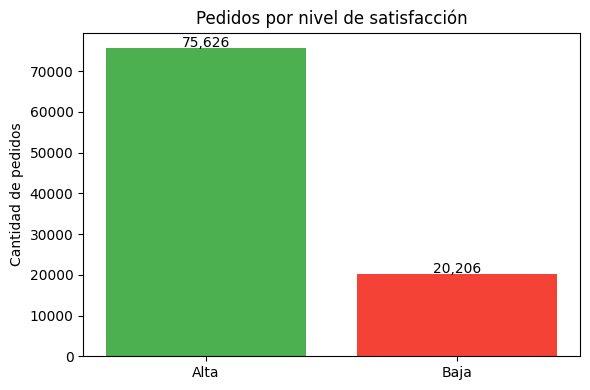

In [237]:
# Visualización: Satisfacción alta vs baja
sat_pd = spark.sql("SELECT CASE WHEN review_score >= 4 THEN 'Alta' ELSE 'Baja' END AS satisfaccion, COUNT(*) AS cantidad FROM olist_master GROUP BY satisfaccion").toPandas()

plt.figure(figsize=(6, 4))
plt.bar(sat_pd["satisfaccion"], sat_pd["cantidad"], color=["#4CAF50", "#F44336"])
plt.title("Pedidos por nivel de satisfacción")
plt.ylabel("Cantidad de pedidos")
for i, v in enumerate(sat_pd["cantidad"]):
    plt.text(i, v + 200, f"{v:,}", ha="center")
plt.tight_layout()
plt.savefig(OUT_PATH + "satisfaccion_alta_baja.png", dpi=120)
plt.show()

In [238]:
# Consulta 8: Satisfacción promedio por categoría de producto
spark.sql("""
    SELECT
        product_category_name        AS categoria,
        COUNT(*)                     AS cantidad,
        ROUND(AVG(review_score), 2)  AS satisfaccion_prom,
        ROUND(AVG(price), 2)         AS precio_prom
    FROM olist_items_detalle
    WHERE product_category_name IS NOT NULL
    GROUP BY product_category_name
    ORDER BY satisfaccion_prom DESC
    LIMIT 10
""").show()

+--------------------+--------+-----------------+-----------+
|           categoria|cantidad|satisfaccion_prom|precio_prom|
+--------------------+--------+-----------------+-----------+
|   cds_dvds_musicais|      14|             4.64|      52.14|
|fashion_roupa_inf...|       8|              4.5|      71.23|
|livros_interesse_...|     553|             4.45|      84.73|
|construcao_ferram...|     103|             4.44|     154.41|
|              flores|      33|             4.42|      33.64|
|   livros_importados|      60|              4.4|      77.33|
|     livros_tecnicos|     267|             4.36|      71.52|
|    malas_acessorios|    1092|             4.32|      128.6|
|   alimentos_bebidas|     278|             4.31|       54.6|
|portateis_casa_fo...|      76|              4.3|     624.29|
+--------------------+--------+-----------------+-----------+



Las categorías con mayor satisfacción son cds_dvds_musicais (4.64), fashion_roupa_infantil (4.50) y livros_interesse_geral (4.45).

Las categorías de libros aparecen frecuentemente en el top, lo que sugiere que los clientes que compran libros tienden a quedar más satisfechos.

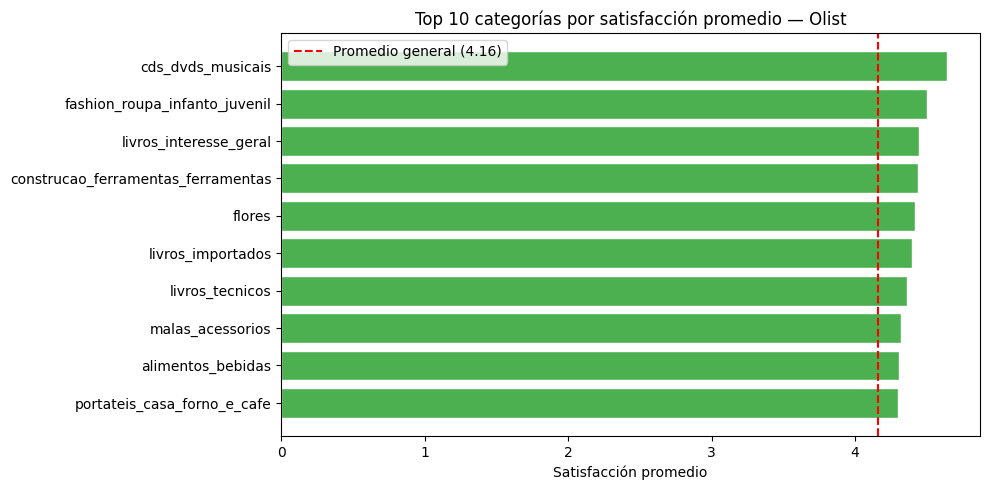

In [239]:
# Visualización: Top 10 categorías por satisfacción promedio
cat_pd = spark.sql("""
    SELECT product_category_name AS categoria,
           ROUND(AVG(review_score), 2) AS satisfaccion_prom
    FROM olist_items_detalle
    WHERE product_category_name IS NOT NULL
    GROUP BY product_category_name
    ORDER BY satisfaccion_prom DESC
    LIMIT 10
""").toPandas()

plt.figure(figsize=(10, 5))
plt.barh(cat_pd["categoria"][::-1], cat_pd["satisfaccion_prom"][::-1], color="#4CAF50", edgecolor="white")
plt.title("Top 10 categorías por satisfacción promedio — Olist")
plt.xlabel("Satisfacción promedio")
plt.axvline(x=4.16, color="red", linestyle="--", label="Promedio general (4.16)")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_PATH + "top_categorias_satisfaccion.png", dpi=120)
plt.show()

In [240]:
# Consulta 9: Precio vs Satisfacción
spark.sql("""
    SELECT
        CASE
            WHEN order_total < 50   THEN 'Bajo (< 50)'
            WHEN order_total < 150  THEN 'Medio (50-150)'
            WHEN order_total < 500  THEN 'Alto (150-500)'
            ELSE 'Premium (> 500)'
        END                             AS rango_precio,
        COUNT(*)                        AS pedidos,
        ROUND(AVG(review_score), 2)     AS satisfaccion_prom
    FROM olist_master
    GROUP BY rango_precio
    ORDER BY satisfaccion_prom DESC
""").show()

+---------------+-------+-----------------+
|   rango_precio|pedidos|satisfaccion_prom|
+---------------+-------+-----------------+
|    Bajo (< 50)|  16378|             4.25|
| Medio (50-150)|  48417|             4.18|
| Alto (150-500)|  27005|             4.08|
|Premium (> 500)|   4032|              4.0|
+---------------+-------+-----------------+



Esto confirma un patrón muy claro: a mayor precio, menor satisfacción.

- Pedidos baratos (< BRL 50): satisfacción 4.25
- Pedidos premium (> BRL 500): satisfacción 4.00

Es consistente con lo que vimos antes, que las compras más caras generan más expectativas y son más difíciles de cumplir.

In [241]:
# Consulta 10: Relación entre flete y satisfacción por rango de flete
spark.sql("""
    SELECT
        CASE
            WHEN freight_total < 10  THEN 'Bajo (< 10)'
            WHEN freight_total < 25  THEN 'Medio (10-25)'
            WHEN freight_total < 50  THEN 'Alto (25-50)'
            ELSE 'Muy alto (> 50)'
        END                             AS rango_flete,
        COUNT(*)                        AS pedidos,
        ROUND(AVG(review_score), 2)     AS satisfaccion_prom
    FROM olist_master
    GROUP BY rango_flete
    ORDER BY satisfaccion_prom DESC
""").show()

+---------------+-------+-----------------+
|    rango_flete|pedidos|satisfaccion_prom|
+---------------+-------+-----------------+
|    Bajo (< 10)|  11013|             4.35|
|  Medio (10-25)|  61948|             4.21|
|   Alto (25-50)|  16822|             3.96|
|Muy alto (> 50)|   6049|             3.85|
+---------------+-------+-----------------+



El flete impacta directamente en la satisfacción del cliente. A mayor costo de envío, menor satisfacción:

- Flete bajo (< BRL 10): satisfacción 4.35 = los mejores evaluados.
- Flete medio (BRL 10-25): satisfacción 4.21 = la mayoría de pedidos (61.948).
- Flete alto (BRL 25-50): satisfacción 3.96, cae por debajo del promedio general (4.16).
- Flete muy alto (> BRL 50): satisfacción 3.85 = los peores evaluados.

Esto confirma que el costo de envío es uno de los factores más determinantes en la experiencia del cliente, más aún que el precio del producto en sí.

In [242]:
# Análisis de Pedidos
# Consulta 11: Pedidos con flete mayor al 30% del valor total
spark.sql("""
    SELECT COUNT(*) AS pedidos_flete_alto,
           ROUND(AVG(review_score), 2) AS satisfaccion_prom
    FROM olist_master
    WHERE (freight_total / order_total) > 0.3
""").show()

+------------------+-----------------+
|pedidos_flete_alto|satisfaccion_prom|
+------------------+-----------------+
|             19700|             4.11|
+------------------+-----------------+



Hay 19.700 pedidos que tienen flete mayor al 30% del valor total, y su satisfacción promedio (4.11) es ligeramente menor al promedio general (4.16). El flete alto impacta negativamente en la satisfacción.

In [243]:
# Consulta 12: Pedidos con múltiples ítems vs ítem único
spark.sql("""
    SELECT
        CASE WHEN n_items = 1 THEN 'Un ítem'
             ELSE 'Múltiples ítems' END   AS tipo_pedido,
        COUNT(*)                          AS cantidad,
        ROUND(AVG(review_score), 2)       AS satisfaccion_prom,
        ROUND(AVG(order_total), 2)        AS ticket_prom
    FROM olist_master
    GROUP BY tipo_pedido
    ORDER BY tipo_pedido
""").show()

+---------------+--------+-----------------+-----------+
|    tipo_pedido|cantidad|satisfaccion_prom|ticket_prom|
+---------------+--------+-----------------+-----------+
|Múltiples ítems|    9528|             3.63|     248.26|
|        Un ítem|   86304|             4.21|     149.77|
+---------------+--------+-----------------+-----------+



Los pedidos con múltiples ítems tienen menor satisfacción y mayor valor, probablemente porque son más complejos de entregar y generan más expectativas.

In [244]:
# Guardar en formato Parquet
df_master.write.mode("overwrite").parquet(OUT_PATH + "olist_master.parquet")
print("Archivo Parquet guardado: olist_master.parquet")

df_items_detalle.write.mode("overwrite").parquet(OUT_PATH + "olist_items_detalle.parquet")
print("Archivo Parquet guardado: olist_items_detalle.parquet")

Archivo Parquet guardado: olist_master.parquet
Archivo Parquet guardado: olist_items_detalle.parquet


## **Lección 5 - *Introducción a Machine Learning Escalable (Spark MLlib)***

📌 **Objetivo:** Construir un pipeline de MLlib para clasificación y segmentación
de usuarios.

📍 **Tareas solicitadas en el ejercicio:**
1. Cargar los DataFrames procesados en la etapa anterior.
2. Crear features con VectorAssembler e indexar categorías con StringIndexer.
3. Entrenar un modelo supervisado (Regresión Logística) y uno no supervisado (K-Means).
4. Evaluar métricas y generar un reporte final con insights para marketing.
5. Entregar pipeline completo en notebook + informe final en PDF.

In [245]:
# Importaciones
from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, ClusteringEvaluator

In [314]:
# Cargar datos desde Parquet
df_ml = spark.read.parquet(OUT_PATH + "olist_master.parquet")

# Agregar categoría desde olist_items_detalle (una por pedido)
df_cat = spark.read.parquet(OUT_PATH + "olist_items_detalle.parquet") \
    .select("order_id", "product_category_name") \
    .dropDuplicates(["order_id"])

df_ml = df_ml.join(df_cat, "order_id", "left")

print(f"Filas cargadas: {df_ml.count():,}")
df_ml.printSchema()
df_ml.show(5)

Filas cargadas: 95,832
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- n_items: long (nullable = true)
 |-- revenue: double (nullable = true)
 |-- freight_total: double (nullable = true)
 |-- order_total: double (nullable = true)
 |-- review_score: double (nullable = true)
 |-- product_category_name: string (nullable = true)

+--------------------+--------------------+------------+-------+-------+-------------+-----------+------------+---------------------+
|            order_id|         customer_id|order_status|n_items|revenue|freight_total|order_total|review_score|product_category_name|
+--------------------+--------------------+------------+-------+-------+-------------+-----------+------------+---------------------+
|ed40c8b2d8208b703...|4407ef2464ce9eb7f...|   delivered|      1|   40.0|         14.1|       54.1|         5.0|    moveis_escritorio|
|5bb903913b74e92c0...|fd4e7e43747ed4434...|   d

In [315]:
df_ml.summary().show()

+-------+--------------------+--------------------+------------+------------------+------------------+------------------+------------------+-----------------+---------------------+
|summary|            order_id|         customer_id|order_status|           n_items|           revenue|     freight_total|       order_total|     review_score|product_category_name|
+-------+--------------------+--------------------+------------+------------------+------------------+------------------+------------------+-----------------+---------------------+
|  count|               95832|               95832|       95832|             95832|             95832|             95832|             95832|            95832|                94482|
|   mean|                NULL|                NULL|        NULL|1.1412680524250771|136.80183686039408|22.762330745470365|159.56416760580623|4.156186451289757|                 NULL|
| stddev|                NULL|                NULL|        NULL|0.5340852758758783|207.78088673

- n_items: 75% de los pedidos tiene 1 ítem = dato muy concentrado.
- review_score: mediana de 5.0 = la mayoría de clientes está muy satisfecho.
- revenue: máximo BRL 13.440 = Hay outliers importantes.
- freight_total: mínimo 0 y máximo BRL 1.794 = gran variabilidad
- order_total: promedio BRL 159, pero máximo BRL 13.664 = distribución muy asimétrica.
- product_category_name: 94.482 valores válidos, 1.350 nulos, o sea hay 1.350 productos sin categoría.

Esto nos dice que el modelo va a trabajar con datos que tienen  mucha variabilidad, especialmente en revenue y order_total.

### **Modelo Supervisado**: Regresión Logística para clasificar pedidos satisfechos vs insatisfechos.

Los outliers en revenue y order_total pueden influir en los coeficientes de la Regresión Logística, aunque este modelo es relativamente robusto frente a valores extremos comparado con otros algoritmos.

In [316]:
# Variable target
# satisfaccion_alta = 1 si review_score >= 4, 0 si no
df_ml = df_ml.withColumn(
    "satisfaccion_alta",
    when(col("review_score") >= 4, 1).otherwise(0)
)

print("Balance de clases:")
df_ml.groupBy("satisfaccion_alta").count().orderBy("satisfaccion_alta").show()

Balance de clases:
+-----------------+-----+
|satisfaccion_alta|count|
+-----------------+-----+
|                0|20206|
|                1|75626|
+-----------------+-----+



75.626 satisfechos (1) → 79%

20.206 insatisfechos (0) → 21%

El dataset está desbalanceado

In [317]:
# StringIndexer: convierte product_category_name en índice numérico
indexer = StringIndexer(inputCol="product_category_name", outputCol="categoria_idx", handleInvalid="keep")
df_ml = indexer.fit(df_ml).transform(df_ml)

# Target encoding: promedio de review_score por categoría
target_enc = df_ml.groupBy("product_category_name") \
    .agg(avg("review_score").alias("categoria_score_prom"))

df_ml = df_ml.join(target_enc, "product_category_name", "left")

# Rellenar nulls en categoria_score_prom con el promedio general
media_general = df_ml.agg(avg("categoria_score_prom")).collect()[0][0]
df_ml = df_ml.fillna({"categoria_score_prom": media_general})

print("Categorías indexadas y con target encoding:")
df_ml.select("product_category_name", "categoria_idx", "categoria_score_prom").show(5)

Categorías indexadas y con target encoding:
+---------------------+-------------+--------------------+
|product_category_name|categoria_idx|categoria_score_prom|
+---------------------+-------------+--------------------+
|    moveis_escritorio|         18.0|  3.6492718446601944|
|        esporte_lazer|          2.0|   4.233382570162481|
|      eletroportateis|         23.0|   4.266222961730449|
|         beleza_saude|          1.0|   4.235088764307405|
|           automotivo|          8.0|   4.151788079470198|
+---------------------+-------------+--------------------+
only showing top 5 rows


*Nota: Se calculan categoria_idx y categoria_score_prom como análisis exploratorio de las categorías. Sin embargo, no se incluyen como variable del modelo, porque categoria_score_prom está construida con review_score, que es la misma variable que queremos predecir.*

In [318]:
# VectorAssembler: combinar features en un solo vector X
X_assembler = VectorAssembler(
    inputCols=["n_items", "revenue", "freight_total"],
    outputCol="X",
    handleInvalid="keep"
)

df_ml = X_assembler.transform(df_ml).select("X", "satisfaccion_alta", "customer_id")
df_ml.show(5)

+-----------------+-----------------+--------------------+
|                X|satisfaccion_alta|         customer_id|
+-----------------+-----------------+--------------------+
|  [1.0,40.0,14.1]|                1|4407ef2464ce9eb7f...|
| [1.0,69.9,18.06]|                1|fd4e7e43747ed4434...|
|[1.0,328.0,36.75]|                1|9afb7d75b5d928401...|
| [1.0,99.9,18.27]|                1|9d46b89032f34a487...|
|[1.0,199.9,26.24]|                1|e47a5eaa9f946c91b...|
+-----------------+-----------------+--------------------+
only showing top 5 rows


In [319]:
# Split train/test 70/30
train_df, test_df = df_ml.randomSplit([0.7, 0.3], seed=42)

# StandardScaler
scaler_lr = StandardScaler(inputCol="X", outputCol="X_scaled", withMean=False, withStd=True)
scaler_lr_model = scaler_lr.fit(train_df)

train_df = scaler_lr_model.transform(train_df).select("X_scaled", "satisfaccion_alta", "customer_id") \
    .withColumnRenamed("X_scaled", "X")
test_df = scaler_lr_model.transform(test_df).select("X_scaled", "satisfaccion_alta", "customer_id") \
    .withColumnRenamed("X_scaled", "X")

print(f"Train: {train_df.count():,} | Test: {test_df.count():,}")

Train: 67,283 | Test: 28,549


In [320]:
# Modelo supervisado: Regresión Logística
lr = LogisticRegression(labelCol="satisfaccion_alta", featuresCol="X")

modelo_lr = lr.fit(train_df)
pred_lr = modelo_lr.transform(test_df)
pred_lr.show(5)

+--------------------+-----------------+--------------------+--------------------+--------------------+----------+
|                   X|satisfaccion_alta|         customer_id|       rawPrediction|         probability|prediction|
+--------------------+-----------------+--------------------+--------------------+--------------------+----------+
|[1.85686682531726...|                1|a790343ca6f3fee08...|[-1.4368660320551...|[0.19203113065073...|       1.0|
|[1.85686682531726...|                1|046f890135acc703f...|[-1.4356765904403...|[0.19221574627820...|       1.0|
|[1.85686682531726...|                0|0253cea0ff18bf585...|[-1.4179213858333...|[0.19498765154732...|       1.0|
|[1.85686682531726...|                0|211558da2c2cdbbd6...|[-1.4179547259884...|[0.19498241828084...|       1.0|
|[1.85686682531726...|                0|e1aa4b904d0a6d58c...|[-1.4180425217300...|[0.19496863785496...|       1.0|
+--------------------+-----------------+--------------------+-------------------

In [321]:
# Evaluación - Regresión Logística
evaluator = MulticlassClassificationEvaluator(labelCol="satisfaccion_alta", predictionCol="prediction", metricName="accuracy")

accuracy = evaluator.evaluate(pred_lr)
f1 = evaluator.evaluate(pred_lr, {evaluator.metricName: "f1"})
precision = evaluator.evaluate(pred_lr, {evaluator.metricName: "weightedPrecision"})
recall = evaluator.evaluate(pred_lr, {evaluator.metricName: "weightedRecall"})

print("Evaluación - Regresión Logística")
print(f"Accuracy  : {accuracy:.4f} ({accuracy:.2%})")
print(f"F1-score  : {f1:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")

Evaluación - Regresión Logística
Accuracy  : 0.7875 (78.75%)
F1-score  : 0.6991
Precision : 0.7106
Recall    : 0.7875


El F1-score de 0.6991 es más representativo que la accuracy (78.75%), ya que considera el desbalance del dataset. El modelo tiene dificultades para identificar correctamente los pedidos insatisfechos, que son justamente los más importantes para el negocio.

In [322]:
# Matriz de confusión
pred_lr.groupBy("satisfaccion_alta", "prediction").count().orderBy("satisfaccion_alta", "prediction").show()

+-----------------+----------+-----+
|satisfaccion_alta|prediction|count|
+-----------------+----------+-----+
|                0|       0.0|   67|
|                0|       1.0| 5972|
|                1|       0.0|   94|
|                1|       1.0|22416|
+-----------------+----------+-----+



- Verdaderos negativos (0→0): solo 67 — el modelo casi no detecta insatisfechos.
- Falsos positivos (0→1): 5.972 — predice satisfecho cuando no lo es.
- Falsos negativos (1→0): 94 — pocos satisfechos mal clasificados.
- Verdaderos positivos (1→1): 22.416 — detecta bien los satisfechos.

El modelo logra una accuracy de 78.75% y F1-score de 0.6991, pero la matriz de confusión revela su limitación principal: solo identifica correctamente 67 de los 6.039 pedidos realmente insatisfechos.

Esto significa que el modelo tiene baja capacidad para detectar clientes insatisfechos, que son precisamente los casos más valiosos para intervención de marketing y postventa. Un modelo útil para el negocio debería priorizar el recall de la clase 0 (insatisfechos)
por encima de la accuracy global.

Así que analizaremos balancear el dataset o ajustar el umbral de decisión del modelo a continuación para ver si esto mejora la detección de clientes insatisfechos.

1. En el primer caso de balancear el dataset, la idea es que el modelo vea más ejemplos de la clase minoritaria (insatisfechos, 21%) para aprender mejor. Hay dos formas:
    - Sobremuestreo: duplicar aleatoriamente filas de insatisfechos hasta equilibrar.
    - classWeight: indicarle al modelo que los insatisfechos "pesan más".

2. En el segundo caso de ajustar el umbral. En lugar del umbral por defecto de 0.5, bajar a 0.3 para que el modelo prediga insatisfecho más fácilmente.

In [323]:
# Opción 1: Balancear dataset con sobremuestreo
df_mayoria = train_df.filter(col("satisfaccion_alta") == 1)
df_minoria = train_df.filter(col("satisfaccion_alta") == 0)

ratio = df_mayoria.count() / df_minoria.count()
df_minoria_sobre = df_minoria.sample(withReplacement=True, fraction=ratio, seed=42)
train_balanceado = df_mayoria.union(df_minoria_sobre)

print("Balance después del sobremuestreo:")
train_balanceado.groupBy("satisfaccion_alta").count().orderBy("satisfaccion_alta").show()
print(f"Total train balanceado: {train_balanceado.count():,}")

Balance después del sobremuestreo:
+-----------------+-----+
|satisfaccion_alta|count|
+-----------------+-----+
|                0|53203|
|                1|53116|
+-----------------+-----+

Total train balanceado: 106,319


In [324]:
# Entrenar modelo con dataset balanceado
lr_bal = LogisticRegression(labelCol="satisfaccion_alta", featuresCol="X")
modelo_bal = lr_bal.fit(train_balanceado)
pred_bal = modelo_bal.transform(test_df)

# Evaluación
accuracy_bal = evaluator.evaluate(pred_bal)
f1_bal = evaluator.evaluate(pred_bal, {evaluator.metricName: "f1"})

print("Evaluación — Modelo con sobremuestreo:")
print(f"Accuracy  : {accuracy_bal:.4f} ({accuracy_bal:.2%})")
print(f"F1-score  : {f1_bal:.4f}")

# Matriz de confusión
print("\nMatriz de confusión:")
pred_bal.groupBy("satisfaccion_alta", "prediction").count().orderBy("satisfaccion_alta", "prediction").show()

Evaluación — Modelo con sobremuestreo:
Accuracy  : 0.7240 (72.40%)
F1-score  : 0.7112

Matriz de confusión:
+-----------------+----------+-----+
|satisfaccion_alta|prediction|count|
+-----------------+----------+-----+
|                0|       0.0| 1449|
|                0|       1.0| 4590|
|                1|       0.0| 3289|
|                1|       1.0|19221|
+-----------------+----------+-----+



Podemos ver que ahora el modelo:
- Detecta 1.449 insatisfechos vs solo 67 antes (21 veces más).
- El F1 subió levemente de 0.6991 a 0.7112.
- La accuracy bajó, así que  el modelo ahora se equivoca más con los satisfechos (3.289 falsos negativos vs 94 antes).

Este modelo es más útil para el negocio, porque el objetivo del negocio es identificar clientes insatisfechos para tomar acciones sobre estos.

In [325]:
# Opción 2: classWeight
n_total = train_df.count()
n_satisfechos = train_df.filter(col("satisfaccion_alta") == 1).count()
n_insatisfechos = train_df.filter(col("satisfaccion_alta") == 0).count()

peso_satisfechos = n_total / (2 * n_satisfechos)
peso_insatisfechos = n_total / (2 * n_insatisfechos)

print(f"Peso satisfechos   : {peso_satisfechos:.4f}")
print(f"Peso insatisfechos : {peso_insatisfechos:.4f}")

# Agregar columna de pesos al DataFrame
train_pesos = train_df.withColumn("peso", when(col("satisfaccion_alta") == 0, peso_insatisfechos)
    .otherwise(peso_satisfechos)
)

# Entrenar modelo con pesos
lr_pesos = LogisticRegression(labelCol="satisfaccion_alta", featuresCol="X", weightCol="peso")
modelo_pesos = lr_pesos.fit(train_pesos)
pred_pesos = modelo_pesos.transform(test_df)

# Evaluación
accuracy_p = evaluator.evaluate(pred_pesos)
f1_p = evaluator.evaluate(pred_pesos, {evaluator.metricName: "f1"})

print("\nEvaluación — Modelo con classWeight:")
print(f"Accuracy  : {accuracy_p:.4f} ({accuracy_p:.2%})")
print(f"F1-score  : {f1_p:.4f}")

print("\nMatriz de confusión:")
pred_pesos.groupBy("satisfaccion_alta", "prediction").count().orderBy("satisfaccion_alta", "prediction").show()

Peso satisfechos   : 0.6334
Peso insatisfechos : 2.3746

Evaluación — Modelo con classWeight:
Accuracy  : 0.7225 (72.25%)
F1-score  : 0.7104

Matriz de confusión:
+-----------------+----------+-----+
|satisfaccion_alta|prediction|count|
+-----------------+----------+-----+
|                0|       0.0| 1458|
|                0|       1.0| 4581|
|                1|       0.0| 3341|
|                1|       1.0|19169|
+-----------------+----------+-----+



Sobremuestreo y ClassWeight dan resultados casi idénticos.

In [326]:
# Opción 3: Ajustar umbral de decisión
from pyspark.ml.functions import vector_to_array

umbral = 0.3
pred_umbral = pred_lr.withColumn(
    "prob_array", vector_to_array(col("probability"))
).withColumn(
    "prediction_ajustada",
    when(col("prob_array")[0] > umbral, 0.0).otherwise(1.0)
)

# Evaluación
evaluator_u = MulticlassClassificationEvaluator(
    labelCol="satisfaccion_alta",
    predictionCol="prediction_ajustada",
    metricName="accuracy"
)

accuracy_u = evaluator_u.evaluate(pred_umbral)
f1_u = evaluator_u.evaluate(pred_umbral, {evaluator_u.metricName: "f1"})

print("Evaluación — Modelo con umbral ajustado (0.3):")
print(f"Accuracy  : {accuracy_u:.4f} ({accuracy_u:.2%})")
print(f"F1-score  : {f1_u:.4f}")

print("\nMatriz de confusión:")
pred_umbral.groupBy("satisfaccion_alta", "prediction_ajustada").count().orderBy("satisfaccion_alta", "prediction_ajustada").show()

Evaluación — Modelo con umbral ajustado (0.3):
Accuracy  : 0.7823 (78.23%)
F1-score  : 0.7104

Matriz de confusión:
+-----------------+-------------------+-----+
|satisfaccion_alta|prediction_ajustada|count|
+-----------------+-------------------+-----+
|                0|                0.0|  314|
|                0|                1.0| 5725|
|                1|                0.0|  491|
|                1|                1.0|22019|
+-----------------+-------------------+-----+



**Comparación de Modelos**

| Métrica | Original | Sobremuestreo | ClassWeight | Umbral 0.3 |
|---------|----------|---------------|-------------|------------|
| Accuracy | 78.75% | 72.40% | 72.25% | 78.23% |
| F1-score | 0.6991 | 0.7112 | 0.7104 | 0.7104 |
| Insatisfechos detectados | 67 de 6.039 | 1.449 de 6.039 | 1.458 de 6.039 | 314 de 6.039 |

Los modelos con sobremuestreo y classWeight detectan significativamente más clientes insatisfechos a costa de una menor accuracy. El ajuste de umbral ofrece un punto medio, ya que detecta 314 insatisfechos manteniendo una accuracy de 78.23%. El modelo original tiene la mejor accuracy, pero es casi inútil para el objetivo de negocio de identificar clientes insatisfechos para intervenir. Por lo que, **el sobremuestreo es el modelo elegido.**

### **Modelo No Supervisado**: K-Means para segmentar clientes/pedidos según comportamiento de compra.

In [327]:
# Agrupar por customer_id para segmentación de usuarios
df_usuarios = spark.read.parquet(OUT_PATH + "olist_master.parquet") \
    .groupBy("customer_id").agg(
        count("order_id").alias("n_pedidos"),
        spark_round(avg("review_score"), 2).alias("tasa_satisfaccion"),
        spark_round(avg("order_total"), 2).alias("gasto_promedio"),
        spark_round(avg("freight_total"), 2).alias("flete_promedio")
    )

print(f"Usuarios únicos: {df_usuarios.count():,}")
df_usuarios.show(5)

Usuarios únicos: 95,832
+--------------------+---------+-----------------+--------------+--------------+
|         customer_id|n_pedidos|tasa_satisfaccion|gasto_promedio|flete_promedio|
+--------------------+---------+-----------------+--------------+--------------+
|f82d1df095bf073a1...|        1|              4.0|        117.57|         27.58|
|39fca5d473f90b6a8...|        1|              5.0|         62.01|         16.11|
|baf94989390857ffc...|        1|              5.0|        146.34|         16.44|
|59b4f1123326b6a40...|        1|              2.0|         68.18|          30.2|
|fb6f8e0cb2c65dfad...|        1|              5.0|        155.27|         38.37|
+--------------------+---------+-----------------+--------------+--------------+
only showing top 5 rows


Existen 95.832 usuarios únicos, lo que coincide con el total de pedidos del DataFrame maestro. Esto indica que casi todos los clientes realizaron un solo pedido en el período analizado.

Por lo tanto, la segmentación K-Means refleja más bien **perfiles de compra** que trayectorias de clientes recurrentes. Para una segmentación más robusta
se necesitaría un dataset con mayor historial de compras por cliente.

In [ ]:
# VectorAssembler para K-Means: n_pedidos, tasa_satisfaccion, gasto_promedio, flete_promedio
assembler_km = VectorAssembler(
    inputCols=["n_pedidos", "tasa_satisfaccion", "gasto_promedio", "flete_promedio"],
    outputCol="features_raw")

df_usuarios_vec = assembler_km.transform(df_usuarios)

scaler = StandardScaler(inputCol="features_raw", outputCol="features", withMean=True, withStd=True)

scaler_model = scaler.fit(df_usuarios_vec)
df_usuarios_scaled = scaler_model.transform(df_usuarios_vec).select("customer_id", "features")

df_usuarios_scaled.show(5)

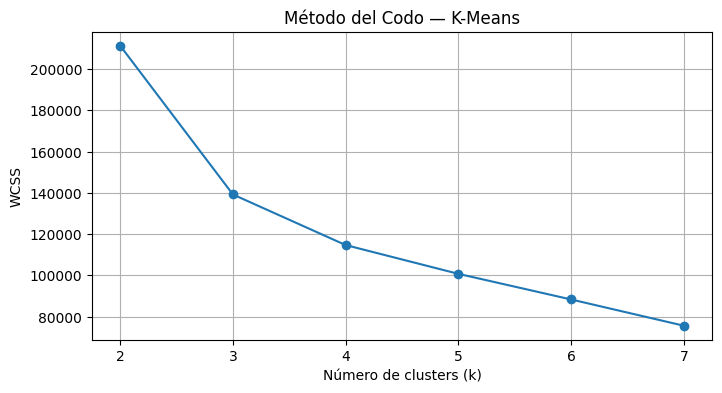

In [328]:
# Método del codo para elegir k óptimo
wcss = []
for k in range(2, 8):
    km = KMeans(featuresCol="features", predictionCol="segmento", k=k, seed=42)
    km_model = km.fit(df_usuarios_scaled)
    wcss.append(km_model.summary.trainingCost)

plt.figure(figsize=(8, 4))
plt.plot(range(2, 8), wcss, marker='o', linestyle='-')
plt.title('Método del Codo — K-Means')
plt.xlabel('Número de clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.savefig(OUT_PATH + "metodo_codo.png", dpi=120)
plt.show()

El método del codo no muestra un quiebre muy marcado, pero se observa una caída importante entre k=2 y k=3, y luego la curva se aplana gradualmente. Se elige k=3 porque ofrece un buen balance entre simplicidad interpretativa y reducción del WCSS, generando 3 segmentos accionables para marketing.

In [ ]:
# K-Means con k=3
kmeans = KMeans(featuresCol="features", predictionCol="segmento", k=3, seed=42)
modelo_km = kmeans.fit(df_usuarios_scaled)
df_segmentado = modelo_km.transform(df_usuarios_scaled)

print("Segmentación completada")
df_segmentado.show(5)

In [ ]:
# Evaluación K-Means
evaluator_km = ClusteringEvaluator(featuresCol="features", predictionCol="segmento", metricName="silhouette")

silhouette = evaluator_km.evaluate(df_segmentado)
print(f"Silhouette Score: {silhouette:.4f}")

In [ ]:
# Perfil de cada segmento
df_usuarios.join(df_segmentado.select("customer_id", "segmento"), "customer_id") \
    .groupBy("segmento").agg(
        count("customer_id").alias("n_usuarios"),
        spark_round(avg("gasto_promedio"), 2).alias("gasto_prom"),
        spark_round(avg("tasa_satisfaccion"), 2).alias("satisfaccion_prom"),
        spark_round(avg("flete_promedio"), 2).alias("flete_prom")
    ).orderBy("segmento").show()

Los 3 segmentos identificados por K-Means revela perfiles de clientes muy distintos:

- Segmento 1 — Clientes Satisfechos (72.510 usuarios): satisfacción 4.75, gasto BRL 127,09. Estrategia: fidelización.
  
- Segmento 2 — Clientes Insatisfechos (19.200 usuarios): satisfacción 1.93, gasto BRL 137,99. Estrategia: recuperación y atención prioritaria.

- Segmento 0 — Clientes Premium (4.122 usuarios): gasto BRL 831,25. Estrategia: programa VIP.

Como se observó anteriormente, la gran mayoría de los clientes tiene exactamente 1 pedido, lo que significa que n_pedidos tiene varianza casi nula y su
aporte al clustering es mínimo.

Para validar esto, se comparan otras dos versiones más del modelo K-Means con distintos conjuntos de features. Así que en el ABP quedaríamos con:

- **V1:** n_pedidos, tasa_satisfaccion, gasto_promedio, flete_promedio
- **V2:** gasto_promedio, flete_promedio (variables económicas)
- **V3:** tasa_satisfaccion, gasto_promedio (experiencia del cliente)

Se consideró incluir revenue como feature alternativa, pero dado que casi todos los clientes tienen 1 solo pedido, gasto_promedio ya captura esa información, así que ambas variables representan el valor de la única
compra del cliente en este dataset.


A continuación, se desarrolla cada versión y al final se comparan los Silhouette Scores para elegir el modelo más adecuado.

In [ ]:
# K-Means V2 — Variables económicas (gasto_promedio, flete_promedio)
assembler_km2 = VectorAssembler(
    inputCols=["gasto_promedio", "flete_promedio"],
    outputCol="features_raw2")

df_usuarios_vec2 = assembler_km2.transform(df_usuarios)

scaler2 = StandardScaler(inputCol="features_raw2", outputCol="features2", withMean=True, withStd=True)
scaler_model2 = scaler2.fit(df_usuarios_vec2)
df_usuarios_scaled2 = scaler_model2.transform(df_usuarios_vec2).select("customer_id", "features2")

# Método del codo
wcss2 = []
for k in range(2, 8):
    km = KMeans(featuresCol="features2", predictionCol="segmento2", k=k, seed=42)
    km_model = km.fit(df_usuarios_scaled2)
    wcss2.append(km_model.summary.trainingCost)

plt.figure(figsize=(8, 4))
plt.plot(range(2, 8), wcss2, marker='o', linestyle='-')
plt.title('Método del Codo — K-Means V2 (variables económicas)')
plt.xlabel('Número de clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.savefig(OUT_PATH + "metodo_codo_v2.png", dpi=120)
plt.show()

Al igual que en V1, el método del codo sugiere k=3 como el número óptimo de clusters, con la caída más pronunciada entre k=2 y k=3.

In [329]:
# K-Means V2 k=3
kmeans2 = KMeans(featuresCol="features2", predictionCol="segmento2", k=3, seed=42)
modelo_km2 = kmeans2.fit(df_usuarios_scaled2)
df_segmentado2 = modelo_km2.transform(df_usuarios_scaled2)

# Silhouette
silhouette2 = ClusteringEvaluator(featuresCol="features2", predictionCol="segmento2", metricName="silhouette").evaluate(df_segmentado2)
print(f"\nSilhouette Score V2: {silhouette2:.4f} \n")

# Perfil
df_usuarios.join(df_segmentado2.select("customer_id", "segmento2"), "customer_id") \
    .groupBy("segmento2").agg(
        count("customer_id").alias("n_usuarios"),
        spark_round(avg("gasto_promedio"), 2).alias("gasto_prom"),
        spark_round(avg("tasa_satisfaccion"), 2).alias("satisfaccion_prom"),
        spark_round(avg("flete_promedio"), 2).alias("flete_prom")
    ).orderBy("segmento2").show()


Silhouette Score V2: 0.8762 

+---------+----------+----------+-----------------+----------+
|segmento2|n_usuarios|gasto_prom|satisfaccion_prom|flete_prom|
+---------+----------+----------+-----------------+----------+
|        0|     88797|    124.37|             4.18|     18.77|
|        1|      5441|    390.67|             3.84|     78.93|
|        2|      1594|   1331.05|             4.04|     53.69|
+---------+----------+----------+-----------------+----------+



El Silhouette Score subió de 0.7174 a **0.8762**, así que tenemos clusters mucho más definidos.

Los segmentos son distintos a la V1:
- **Segmento 0**: 88.797 usuarios, gasto BRL 124, flete BRL 18 → Clientes regulares
- **Segmento 1**: 5.441 usuarios, gasto BRL 390, flete BRL 78 → Clientes de alto flete
- **Segmento 2**: 1.594 usuarios, gasto BRL 1.331, flete BRL 53 → Clientes premium

La satisfacción es similar en los 3 segmentos (3.84-4.18), así que cuando **no** se incluye satisfacción como feature, el modelo segmenta puramente por valor económico.

In [ ]:
# K-Means V3 — Experiencia del cliente (tasa_satisfaccion, gasto_promedio)
assembler_km3 = VectorAssembler(
    inputCols=["tasa_satisfaccion", "gasto_promedio"],
    outputCol="features_raw3")

df_usuarios_vec3 = assembler_km3.transform(df_usuarios)

scaler3 = StandardScaler(inputCol="features_raw3", outputCol="features3", withMean=True, withStd=True)
scaler_model3 = scaler3.fit(df_usuarios_vec3)
df_usuarios_scaled3 = scaler_model3.transform(df_usuarios_vec3).select("customer_id", "features3")

# Método del codo
wcss3 = []
for k in range(2, 8):
    km = KMeans(featuresCol="features3", predictionCol="segmento3", k=k, seed=42)
    km_model = km.fit(df_usuarios_scaled3)
    wcss3.append(km_model.summary.trainingCost)

plt.figure(figsize=(8, 4))
plt.plot(range(2, 8), wcss3, marker='o', linestyle='-')
plt.title('Método del Codo — K-Means V3 (experiencia del cliente)')
plt.xlabel('Número de clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.savefig(OUT_PATH + "metodo_codo_v3.png", dpi=120)
plt.show()

El método del codo muestra una caída pronunciada entre k=2 y k=3, aunque la curva continúa descendiendo gradualmente hasta k=5. Se elige k=3 por consistencia con las versiones anteriores.

In [ ]:
# K-Means V3 k=3
kmeans3 = KMeans(featuresCol="features3", predictionCol="segmento3", k=3, seed=42)
modelo_km3 = kmeans3.fit(df_usuarios_scaled3)
df_segmentado3 = modelo_km3.transform(df_usuarios_scaled3)

# Silhouette
silhouette3 = ClusteringEvaluator(featuresCol="features3", predictionCol="segmento3", metricName="silhouette").evaluate(df_segmentado3)
print(f"Silhouette Score V3: {silhouette3:.4f}\n")

# Perfil
df_usuarios.join(df_segmentado3.select("customer_id", "segmento3"), "customer_id") \
    .groupBy("segmento3").agg(
        count("customer_id").alias("n_usuarios"),
        spark_round(avg("gasto_promedio"), 2).alias("gasto_prom"),
        spark_round(avg("tasa_satisfaccion"), 2).alias("satisfaccion_prom"),
        spark_round(avg("flete_promedio"), 2).alias("flete_prom")
    ).orderBy("segmento3").show()

Los segmentos de V3 combinan satisfacción y gasto:

- Segmento 0: 73.579 usuarios, satisfacción 4.75, gasto BRL 129 → Clientes Satisfechos
- Segmento 1: 2.601 usuarios, satisfacción 4.15, gasto BRL 1.115 → Clientes Premium
- Segmento 2: 19.652 usuarios, satisfacción 1.93, gasto BRL 144 → Clientes Insatisfechos

A diferencia de V2, esta versión recupera el segmento de insatisfechos (satisfacción 1.93) que es el más valioso para intervención de marketing y postventa. El segmento premium tiene un gasto significativamente mayor (BRL 1.115) con satisfacción moderada (4.15), lo que sugiere que los clientes de mayor valor no son necesariamente los más satisfechos.

**Comparación de versiones K-Means:**

| Métrica | V1 (4 features) | V2 (económicas) | V3 (experiencia) |
|---------|----------------|-----------------|------------------|
| Silhouette | 0.7174 | 0.8762 | 0.8019 |
| Segmento mayor | 72.510 usuarios | 88.797 usuarios | 73.579 usuarios |
| Segmento premium | 4.122 (gasto BRL 831) | 1.594 (gasto BRL 1.331) | 2.601 (gasto BRL 1.115) |
| Segmento insatisfecho | 19.200 (sat 1.93) | no aparece | 19.652 (sat 1.93) |

- V1 tiene el menor Silhouette, pero es más completa en variables.
- V2 tiene el mejor Silhouette (0.8762), pero pierde el segmento de insatisfechos, lo que es justamente nos interesa estudiar.
- V3 tiene buen Silhouette (0.8019) y mantiene el segmento de insatisfechos, combinando satisfacción y gasto.

**Modelo elegido: V3 (tasa_satisfaccion + gasto_promedio)**

In [ ]:
# Visualización: Perfil de Clústers K-Means — Modelo Final V3
perfil_pd = df_usuarios.join(
    df_segmentado3.select("customer_id", "segmento3"), "customer_id"
).groupBy("segmento3").agg(
    avg("gasto_promedio").alias("gasto"),
    avg("tasa_satisfaccion").alias("satisfaccion"),
    avg("flete_promedio").alias("flete")
).toPandas().sort_values("segmento3")

etiquetas = {0: "Satisfechos", 1: "Premium", 2: "Insatisfechos"}
perfil_pd["nombre"] = perfil_pd["segmento3"].map(etiquetas)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colores = ["#2196F3", "#4CAF50", "#FF9800"]

for ax, (col_name, titulo) in zip(axes, [
    ("gasto", "Gasto promedio (BRL)"),
    ("satisfaccion", "Satisfacción promedio"),
    ("flete", "Flete promedio (BRL)")
]):
    ax.bar(perfil_pd["nombre"], perfil_pd[col_name], color=colores, edgecolor="white")
    ax.set_title(titulo)
    ax.set_ylabel("")

plt.suptitle("Perfil de Clústers — K-Means V3 (Modelo Final)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_PATH + "perfil_clusters_v3.png", dpi=120)
plt.show()

En el gráfico se representan 3 segmentos diferenciados:

- Satisfechos (azul): gasto bajo, satisfacción muy alta, flete bajo.
- Premium (verde): gasto muy alto, satisfacción moderada, flete alto.
- Insatisfechos (naranja): gasto bajo, satisfacción muy baja, flete moderado.

In [330]:
# Cierre de SparkSession
#spark.stop()
#print("SparkSession cerrada. Pipeline completo.")

## **Reporte Final**

RetailMax procesó 95.832 pedidos entregados del marketplace Olist usando un pipeline completo de Big Data con Apache Spark.

#### ***Hallazgos principales***

**Satisfacción del cliente**
- El 79% de los clientes tiene alta satisfacción (score ≥ 4).
- El flete alto (>30% del valor total) impacta negativamente en la satisfacción.
- Los pedidos con múltiples ítems tienen menor satisfacción (3.63 vs 4.21).
- El pedido alto y el flete elevado tienden a asociarse con menor satisfacción.

**Categorías de producto**
- Las categorías con mayor satisfacción son: cds_dvds_musicais, fashion_roupa_infantil y livros_interesse_geral.
- Las categorías con mayor venta no coinciden necesariamente con las de mayor satisfacción.

**Modelo Supervisado - Predictivo**: Regresión Logística para clasificar pedidos satisfechos vs insatisfechos.
- Accuracy: 72.40% | F1-score: 0.7112
- El modelo original tiene dificultades para identificar pedidos insatisfechos debido al desbalance del dataset (79% satisfechos vs 21% insatisfechos). Así que se estudiaron tres casos para corregir esto: Sobremuestreo, ClassWeight y cambio de umbral a 0.3.
- Se seleccionó el modelo con sobremuestreo como modelo final, porque detecta 1.449 clientes insatisfechos (vs 67 del modelo original), lo que lo hace significativamente más útil para intervención de marketing y postventa, a pesar de obtener una menor accuracy global (72.40%).

**Modelo No Supervisado:** K-Means para segmentar clientes/pedidos según comportamiento de compra.
- Se compararon tres modelos de K-means con diferentes features. Siendo el modelo V3 el elegido. Este incluia las variables: tasa_satisfaccion, gasto_promedio (experiencia del cliente).
- Segmentación de usuarios:
  - **Segmento Satisfechos (73.579 usuarios)**: satisfacción 4.75, gasto BRL 129 → Estrategia: campañas de fidelización y recompra.
  - **Segmento Premium (2.601 usuarios)**: gasto BRL 1.115, satisfacción 4.15 → Estrategia: programa VIP con beneficios exclusivos.
  - **Segmento Insatisfechos (19.652 usuarios)**: satisfacción 1.93, gasto BRL 144 → Estrategia: recuperación y atención prioritaria postventa.


#### ***Recomendaciones para Marketing***
1. Reducir el costo de flete para pedidos con múltiples ítems.
2. Crear programa de fidelización para los 73.579 clientes Satisfechos.
3. Implementar atención prioritaria para los 19.652 clientes Insatisfechos.
4. Desarrollar programa VIP para los 2.601 clientes Premium.